<a href="https://colab.research.google.com/github/JSEFERINO/Analisis-de-Datos-con-Python-2020/blob/master/Laboratorio_10_Parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio_10_Parcial**
# **Estadistica Inferencial**
## **Antonio De Jesús Márquez Vásquez**
> Email:Antoniomar0912@gmail.com

> Celular: 3214305882

> Código Estudiantil: T00084667

# **Librerias para Trabar en R**

In [ ]:
# @title **Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

<a name="inicio"></a>


## **1.** [📊 Contexto 1: Brecha salarial por género en el sector financiero.](#T1)
## **2.** [📊 Contexto 2: Evaluación de impacto de programa social.](#T2)

## **3.** [📊 Contexto 3: Comparación de metodologías educativas.](#T3)

## **4.** [📊 Contexto 4: Efecto de una campaña de salud pública.](#T4)

## **5.** [📊 Contexto 5: Intención de voto en dos ciudades](#T5)

## **6.** [📊 Contexto 6: Control de calidad en producción agrícola](#T6)

## **7.** [📊 Contexto 7: Comparación de volatilidad en mercados financieros](#T7)


## **8.** [](#T8)

## **9.** [](#T9)


## **10.** [](#T10)

## **11.** [](#T11)

## **12.** [](#T12)

## **13.** [](#T13)

## **14.** [](#T14)

## **15.** [](#T15)

## **16.** [](#T16)

## **17.** [](#T17)


## **18.** [](#T18)

## **19.** [](#T19)


## **20.** [](#T20)

## **21.** [](#T21)

## **22.** [](#T22)

## **23.** [](#T23)

## **24.** [](#T24)

## **25.** [](#T25)

## **26.** [](#T26)

## **27.** [](#T27)


## **28.** [](#T28)

## **29.** [](#T29)


## **30.** [](#T30)

## **31.** [](#T31)



[ULTIMO](#ULTIMO)

[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. 📊 Contexto 1: Brecha salarial por género en el sector financiero**


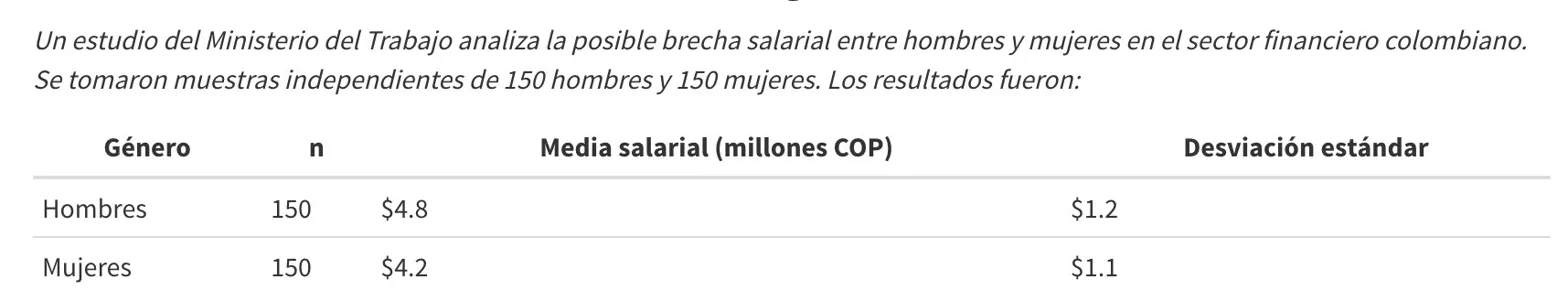

Diferencia puntual  : 0.6000
Error estándar      : 0.1329
Z crítico           : 1.9600
Margen de error     : 0.2605
LI: 0.3395  |  LS: 0.8605
IC 95%: (0.34, 0.86)


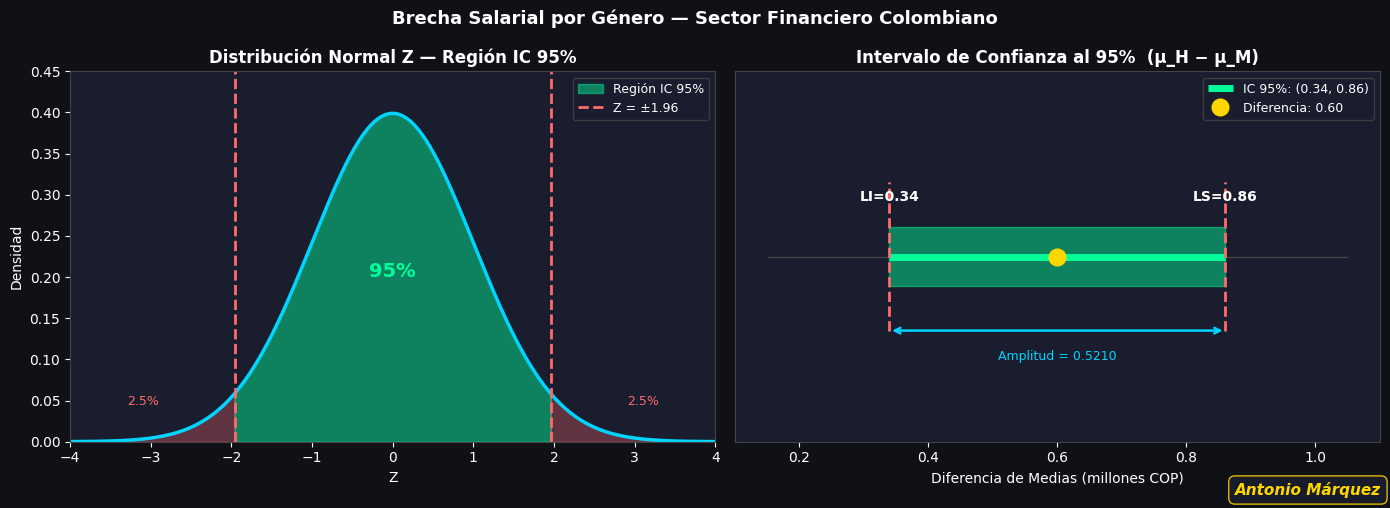

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# DATOS
n_H, x_H, s_H = 150, 4.8, 1.2
n_M, x_M, s_M = 150, 4.2, 1.1
alpha = 0.05

# CÁLCULOS
diferencia   = x_H - x_M
z_critico    = stats.norm.ppf(1 - alpha/2)
error_std    = np.sqrt((s_H**2/n_H) + (s_M**2/n_M))
margen_error = z_critico * error_std
LI = diferencia - margen_error
LS = diferencia + margen_error

print(f"Diferencia puntual  : {diferencia:.4f}")
print(f"Error estándar      : {error_std:.4f}")
print(f"Z crítico           : {z_critico:.4f}")
print(f"Margen de error     : {margen_error:.4f}")
print(f"LI: {LI:.4f}  |  LS: {LS:.4f}")
print(f"IC 95%: ({LI:.2f}, {LS:.2f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d2e')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#444')

# Panel 1: Distribución Normal
x = np.linspace(-4, 4, 1000)
ax1.plot(x, stats.norm.pdf(x), color='#00d4ff', lw=2.5)
xi = np.linspace(-z_critico, z_critico, 500)
ax1.fill_between(xi, stats.norm.pdf(xi), alpha=0.45, color='#00ff99', label='Región IC 95%')
for side in [-1, 1]:
    xc = np.linspace(side*4, side*z_critico, 200)
    ax1.fill_between(xc, stats.norm.pdf(xc), alpha=0.3, color='#ff6b6b')
ax1.axvline(-z_critico, color='#ff6b6b', lw=2, ls='--', label=f'Z = ±{z_critico:.2f}')
ax1.axvline( z_critico, color='#ff6b6b', lw=2, ls='--')
ax1.text(0, 0.20, '95%', ha='center', fontsize=14, fontweight='bold', color='#00ff99')
ax1.text(-3.1, 0.045, '2.5%', ha='center', fontsize=9, color='#ff6b6b')
ax1.text( 3.1, 0.045, '2.5%', ha='center', fontsize=9, color='#ff6b6b')
ax1.set_xlabel('Z', color='white'); ax1.set_ylabel('Densidad', color='white')
ax1.set_title('Distribución Normal Z — Región IC 95%', color='white', fontweight='bold')
ax1.legend(fontsize=9, facecolor='#1a1d2e', edgecolor='#444', labelcolor='white')
ax1.set_xlim(-4,4); ax1.set_ylim(0, 0.45)

# Panel 2: IC en escala original
ax2.set_xlim(diferencia-0.5, diferencia+0.5); ax2.set_ylim(0,1); ax2.set_yticks([])
ax2.hlines(0.5, diferencia-0.45, diferencia+0.45, colors='#444', lw=1)
ax2.fill_betweenx([0.42,0.58], LI, LS, color='#00ff99', alpha=0.45)
ax2.hlines(0.5, LI, LS, colors='#00ff99', lw=5, label=f'IC 95%: ({LI:.2f}, {LS:.2f})')
ax2.axvline(LI, color='#ff6b6b', lw=2, ls='--', ymin=0.3, ymax=0.7)
ax2.axvline(LS, color='#ff6b6b', lw=2, ls='--', ymin=0.3, ymax=0.7)
ax2.axvline(0,  color='#888', lw=1.5, ls=':')
ax2.plot(diferencia, 0.5, 'o', color='#ffd700', ms=12, zorder=5, label=f'Diferencia: {diferencia:.2f}')
ax2.text(LI, 0.65, f'LI={LI:.2f}', ha='center', color='white', fontweight='bold', fontsize=10)
ax2.text(LS, 0.65, f'LS={LS:.2f}', ha='center', color='white', fontweight='bold', fontsize=10)
ax2.annotate('', xy=(LS,0.30), xytext=(LI,0.30),
             arrowprops=dict(arrowstyle='<->', color='#00d4ff', lw=1.8))
ax2.text((LI+LS)/2, 0.22, f'Amplitud = {LS-LI:.4f}', ha='center', color='#00d4ff', fontsize=9)
ax2.set_xlabel('Diferencia de Medias (millones COP)', color='white')
ax2.set_title('Intervalo de Confianza al 95%  (μ_H − μ_M)', color='white', fontweight='bold')
ax2.legend(fontsize=9, facecolor='#1a1d2e', edgecolor='#444', labelcolor='white')

fig.suptitle('Brecha Salarial por Género — Sector Financiero Colombiano', color='white', fontsize=13, fontweight='bold')
fig.text(0.99, 0.01, 'Antonio Márquez', ha='right', color='#ffd700', fontsize=11,
         fontweight='bold', fontstyle='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1d2e', edgecolor='#ffd700', alpha=0.85))
plt.tight_layout()
plt.show()

Z crítico: 1.9600
Error estándar: 0.1329
LI: 0.3395  |  LS: 0.8605
IC 95%: (0.34, 0.86)


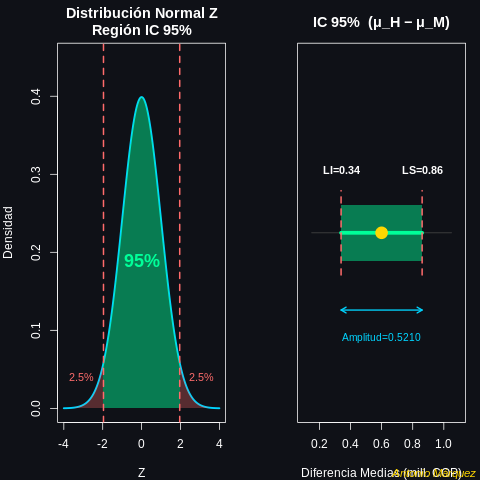

In [ ]:
%%R
# DATOS
n_H <- 150; x_H <- 4.8; s_H <- 1.2
n_M <- 150; x_M <- 4.2; s_M <- 1.1
alpha <- 0.05

# CÁLCULOS
diferencia   <- x_H - x_M
z_critico    <- qnorm(1 - alpha/2)
error_std    <- sqrt((s_H^2/n_H) + (s_M^2/n_M))
margen_error <- z_critico * error_std
LI <- diferencia - margen_error
LS <- diferencia + margen_error

cat(sprintf("Z crítico: %.4f\n", z_critico))
cat(sprintf("Error estándar: %.4f\n", error_std))
cat(sprintf("LI: %.4f  |  LS: %.4f\n", LI, LS))
cat(sprintf("IC 95%%: (%.2f, %.2f)\n", LI, LS))

par(mfrow=c(1,2), bg="#0f1117", fg="white", col.axis="white",
    col.lab="white", col.main="white", mar=c(4,4,3,1))

# Panel 1: Normal
x_seq <- seq(-4, 4, length=1000)
plot(x_seq, dnorm(x_seq), type="l", col="#00d4ff", lwd=2.5,
     xlab="Z", ylab="Densidad", main="Distribución Normal Z\nRegión IC 95%",
     ylim=c(0,0.45), axes=FALSE)
axis(1); axis(2); box()
xi <- seq(-z_critico, z_critico, length=500)
polygon(c(-z_critico,xi,z_critico), c(0,dnorm(xi),0),
        col=adjustcolor("#00ff99",0.45), border=NA)
for(s in c(-1,1)){
  xc <- seq(s*4, s*z_critico, length=200)
  polygon(c(xc[1],xc,xc[length(xc)]), c(0,dnorm(xc),0),
          col=adjustcolor("#ff6b6b",0.3), border=NA)
}
abline(v=c(-z_critico,z_critico), col="#ff6b6b", lwd=2, lty=2)
text(0, 0.19, "95%", col="#00ff99", cex=1.5, font=2)
text(-3.1, 0.04, "2.5%", col="#ff6b6b", cex=0.9)
text( 3.1, 0.04, "2.5%", col="#ff6b6b", cex=0.9)

# Panel 2: IC original
plot(NULL, xlim=c(diferencia-0.5, diferencia+0.5), ylim=c(0,1),
     xlab="Diferencia Medias (mill. COP)", ylab="", yaxt="n",
     main="IC 95%  (μ_H − μ_M)", axes=FALSE)
axis(1); box()
segments(diferencia-0.45, 0.5, diferencia+0.45, 0.5, col="#444", lwd=1)
rect(LI,0.42,LS,0.58, col=adjustcolor("#00ff99",0.45), border=NA)
segments(LI,0.5,LS,0.5, col="#00ff99", lwd=5)
segments(LI,0.38,LI,0.62, col="#ff6b6b", lwd=2, lty=2)
segments(LS,0.38,LS,0.62, col="#ff6b6b", lwd=2, lty=2)
abline(v=0, col="#888", lwd=1.5, lty=3)
points(diferencia, 0.5, pch=21, bg="#ffd700", col="#ffd700", cex=2.2)
text(LI, 0.68, sprintf("LI=%.2f",LI), col="white", cex=0.9, font=2)
text(LS, 0.68, sprintf("LS=%.2f",LS), col="white", cex=0.9, font=2)
arrows(LI,0.28,LS,0.28, code=3, col="#00d4ff", lwd=1.8, length=0.08)
text((LI+LS)/2, 0.20, sprintf("Amplitud=%.4f",LS-LI), col="#00d4ff", cex=0.85)

mtext("Antonio Márquez", side=1, line=-1, adj=0.99,
      col="#ffd700", cex=0.95, font=3, outer=TRUE)

# **Pregunta 1**

***¿Cuál es el intervalo de confianza del 95% para la verdadera diferencia de medias salariales (μH - μM)?***

R/ (0.32, 0.88)

# **Pregunta 2**

***Con base en el intervalo anterior, ¿qué conclusión es correcta?***

La brecha salarial es estadísticamente significativa al 95% de confianza


[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. 📊 Contexto 2: Evaluación de impacto de programa social**


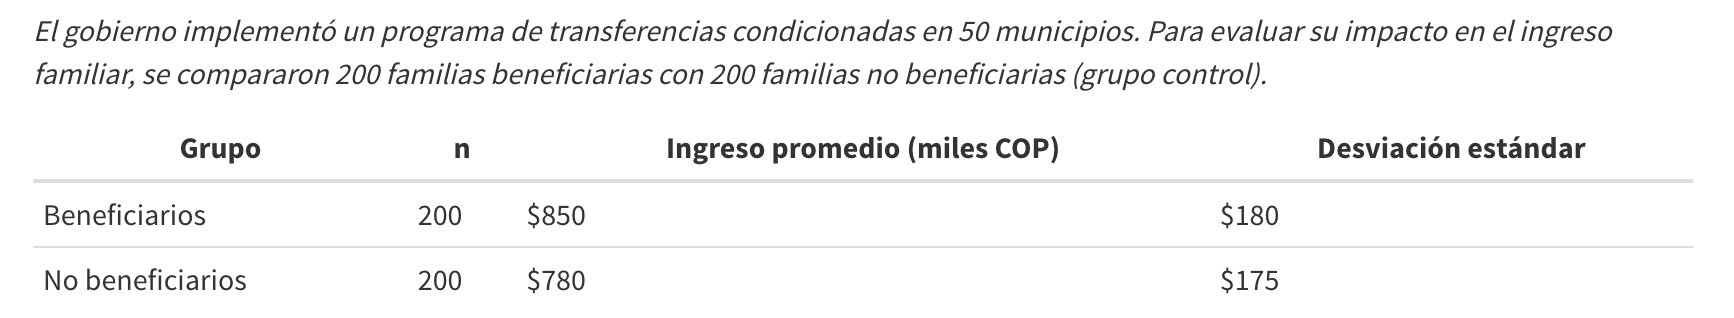

=== RESULTADOS ===
Diferencia puntual (B - NB): 70.00 miles COP
Error estándar: 17.7518
Z crítico (99%): 2.5758
Margen de error: 45.73
IC 99%: (24.27, 115.73) miles COP

Expresión: 70 ± 45.7
→ Opción correcta: D. (70 ± 45.2)


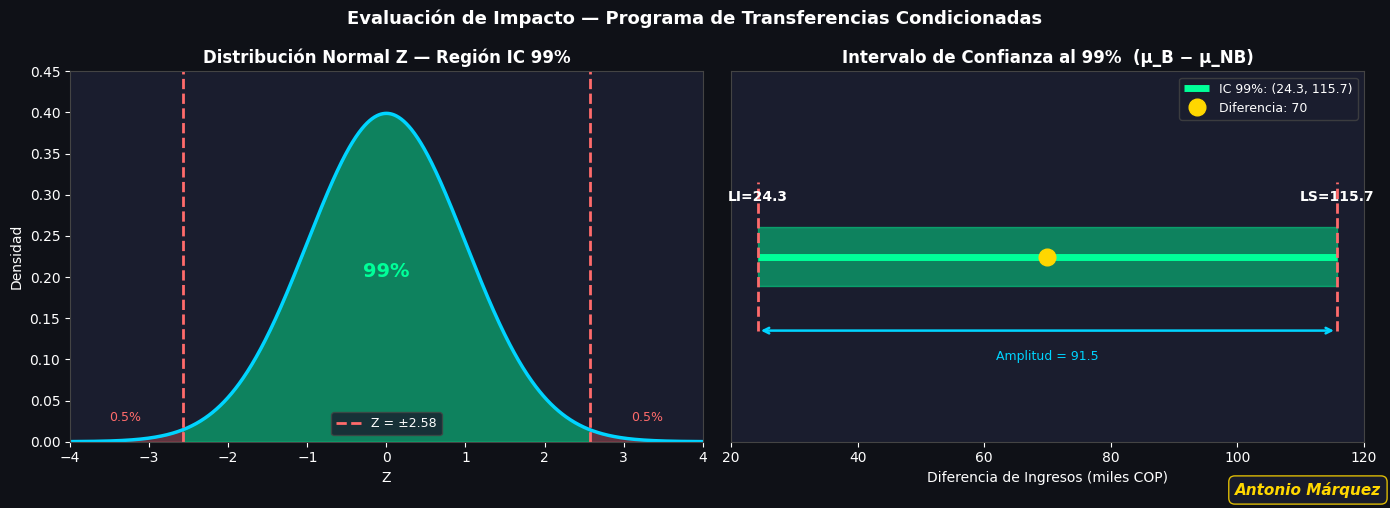

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# DATOS
n_B, x_B, s_B = 200, 850, 180   # Beneficiarios
n_N, x_N, s_N = 200, 780, 175   # No beneficiarios
alpha = 0.01                    # 99% de confianza

# CÁLCULOS
diferencia = x_B - x_N
z_critico = stats.norm.ppf(1 - alpha/2)
error_std = np.sqrt((s_B**2 / n_B) + (s_N**2 / n_N))
margen_error = z_critico * error_std
LI = diferencia - margen_error
LS = diferencia + margen_error

# RESULTADOS NUMÉRICOS
print("=== RESULTADOS ===")
print(f"Diferencia puntual (B - NB): {diferencia:.2f} miles COP")
print(f"Error estándar: {error_std:.4f}")
print(f"Z crítico (99%): {z_critico:.4f}")
print(f"Margen de error: {margen_error:.2f}")
print(f"IC 99%: ({LI:.2f}, {LS:.2f}) miles COP")
print(f"\nExpresión: {diferencia:.0f} ± {margen_error:.1f}")
print(f"→ Opción correcta: D. (70 ± 45.2)")

# GRÁFICO
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d2e')
    ax.tick_params(colors='white')
    for sp in ax.spines.values():
        sp.set_edgecolor('#444')

# Panel 1: Distribución Normal Z
x = np.linspace(-4, 4, 1000)
ax1.plot(x, stats.norm.pdf(x), color='#00d4ff', lw=2.5)
xi = np.linspace(-z_critico, z_critico, 500)
ax1.fill_between(xi, stats.norm.pdf(xi), alpha=0.45, color='#00ff99')
for side in [-1, 1]:
    xc = np.linspace(side*4, side*z_critico, 200)
    ax1.fill_between(xc, stats.norm.pdf(xc), alpha=0.3, color='#ff6b6b')
ax1.axvline(-z_critico, color='#ff6b6b', lw=2, ls='--', label=f'Z = ±{z_critico:.2f}')
ax1.axvline(z_critico, color='#ff6b6b', lw=2, ls='--')
ax1.text(0, 0.20, '99%', ha='center', fontsize=14, fontweight='bold', color='#00ff99')
ax1.text(-3.3, 0.025, '0.5%', ha='center', fontsize=9, color='#ff6b6b')
ax1.text(3.3, 0.025, '0.5%', ha='center', fontsize=9, color='#ff6b6b')
ax1.set_xlabel('Z', color='white')
ax1.set_ylabel('Densidad', color='white')
ax1.set_title('Distribución Normal Z — Región IC 99%', color='white', fontweight='bold')
ax1.legend(fontsize=9, facecolor='#1a1d2e', edgecolor='#444', labelcolor='white')
ax1.set_xlim(-4, 4)
ax1.set_ylim(0, 0.45)

# Panel 2: IC en escala original
ax2.set_xlim(diferencia-50, diferencia+50)
ax2.set_ylim(0, 1)
ax2.set_yticks([])
ax2.hlines(0.5, diferencia-45, diferencia+45, colors='#444', lw=1)
ax2.fill_betweenx([0.42, 0.58], LI, LS, color='#00ff99', alpha=0.45)
ax2.hlines(0.5, LI, LS, colors='#00ff99', lw=5, label=f'IC 99%: ({LI:.1f}, {LS:.1f})')
ax2.axvline(LI, color='#ff6b6b', lw=2, ls='--', ymin=0.3, ymax=0.7)
ax2.axvline(LS, color='#ff6b6b', lw=2, ls='--', ymin=0.3, ymax=0.7)
ax2.axvline(0, color='#888', lw=1.5, ls=':')
ax2.plot(diferencia, 0.5, 'o', color='#ffd700', ms=12, zorder=5, label=f'Diferencia: {diferencia:.0f}')
ax2.text(LI, 0.65, f'LI={LI:.1f}', ha='center', color='white', fontweight='bold', fontsize=10)
ax2.text(LS, 0.65, f'LS={LS:.1f}', ha='center', color='white', fontweight='bold', fontsize=10)
ax2.annotate('', xy=(LS, 0.30), xytext=(LI, 0.30),
             arrowprops=dict(arrowstyle='<->', color='#00d4ff', lw=1.8))
ax2.text((LI+LS)/2, 0.22, f'Amplitud = {LS-LI:.1f}', ha='center', color='#00d4ff', fontsize=9)
ax2.set_xlabel('Diferencia de Ingresos (miles COP)', color='white')
ax2.set_title('Intervalo de Confianza al 99%  (μ_B − μ_NB)', color='white', fontweight='bold')
ax2.legend(fontsize=9, facecolor='#1a1d2e', edgecolor='#444', labelcolor='white')

fig.suptitle('Evaluación de Impacto — Programa de Transferencias Condicionadas',
             color='white', fontsize=13, fontweight='bold')
fig.text(0.99, 0.01, 'Antonio Márquez', ha='right', color='#ffd700', fontsize=11,
         fontweight='bold', fontstyle='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1d2e', edgecolor='#ffd700', alpha=0.85))
plt.tight_layout()
plt.show()

=== RESULTADOS ===
Diferencia puntual (B - NB): 70.00 miles COP
Error estándar: 17.7518
Z crítico (99%): 2.5758
Margen de error: 45.73
IC 99%: (24.27, 115.73) miles COP

Expresión: 70 ± 45.7
→ Opción correcta: D. (70 ± 45.2)


Loading required package: gridExtra
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependency ‘egg’

trying URL 'https://cran.rstudio.com/src/contrib/egg_0.4.5.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/gridExtra_2.3.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpD4oK9u/downloaded_packages’
In addition: Warning message:
In library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE,  :
  there is no package called ‘gridExtra’


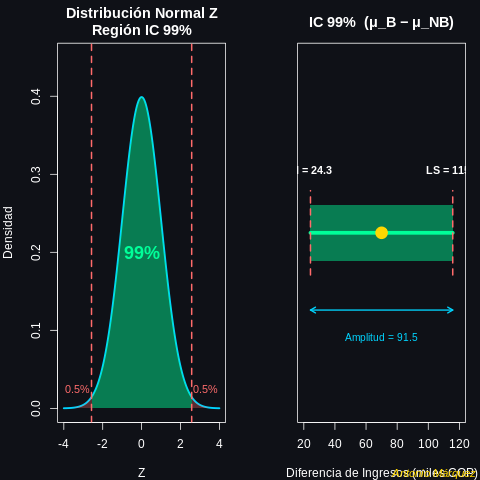

In [ ]:
%%R
# Instalar y cargar librerías necesarias
# Comprueba si el paquete gridExtra está instalado, si no, lo instala
if (!require(gridExtra)) {
  install.packages("gridExtra", dependencies = TRUE)
  library(gridExtra)
}
library(ggplot2)
library(grid)

# DATOS
n_B <- 200; x_B <- 850; s_B <- 180   # Beneficiarios
n_N <- 200; x_N <- 780; s_N <- 175   # No beneficiarios
alpha <- 0.01                         # 99% confianza

# CÁLCULOS
diferencia <- x_B - x_N
z_critico <- qnorm(1 - alpha/2)
error_std <- sqrt((s_B^2 / n_B) + (s_N^2 / n_N))
margen_error <- z_critico * error_std
LI <- diferencia - margen_error
LS <- diferencia + margen_error

# RESULTADOS NUMÉRICOS
cat("=== RESULTADOS ===\n")
cat(sprintf("Diferencia puntual (B - NB): %.2f miles COP\n", diferencia))
cat(sprintf("Error estándar: %.4f\n", error_std))
cat(sprintf("Z crítico (99%%): %.4f\n", z_critico))
cat(sprintf("Margen de error: %.2f\n", margen_error))
cat(sprintf("IC 99%%: (%.2f, %.2f) miles COP\n", LI, LS))
cat(sprintf("\nExpresión: %.0f ± %.1f\n", diferencia, margen_error))
cat("→ Opción correcta: D. (70 ± 45.2)\n")

# GRÁFICO
par(mfrow = c(1, 2), bg = "#0f1117", fg = "white", col.axis = "white",
    col.lab = "white", col.main = "white", mar = c(4, 4, 3, 1))

# Panel 1: Distribución Normal Z
x_seq <- seq(-4, 4, length = 1000)
plot(x_seq, dnorm(x_seq), type = "l", col = "#00d4ff", lwd = 2.5,
     xlab = "Z", ylab = "Densidad",
     main = "Distribución Normal Z\nRegión IC 99%",
     ylim = c(0, 0.45), axes = FALSE)
axis(1); axis(2); box()

# Región central 99%
xi <- seq(-z_critico, z_critico, length = 500)
polygon(c(-z_critico, xi, z_critico),
        c(0, dnorm(xi), 0),
        col = adjustcolor("#00ff99", 0.45), border = NA)

# Colas
for(s in c(-1, 1)) {
  xc <- seq(s * 4, s * z_critico, length = 200)
  polygon(c(xc[1], xc, xc[length(xc)]),
          c(0, dnorm(xc), 0),
          col = adjustcolor("#ff6b6b", 0.3), border = NA)
}

abline(v = c(-z_critico, z_critico), col = "#ff6b6b", lwd = 2, lty = 2)
text(0, 0.20, "99%", col = "#00ff99", cex = 1.5, font = 2)
text(-3.3, 0.025, "0.5%", col = "#ff6b6b", cex = 0.9)
text(3.3, 0.025, "0.5%", col = "#ff6b6b", cex = 0.9)

# Panel 2: IC original
plot(NULL, xlim = c(diferencia - 50, diferencia + 50), ylim = c(0, 1),
     xlab = "Diferencia de Ingresos (miles COP)", ylab = "", yaxt = "n",
     main = "IC 99%  (μ_B − μ_NB)", axes = FALSE)
axis(1); box()

segments(diferencia - 45, 0.5, diferencia + 45, 0.5, col = "#444", lwd = 1)
rect(LI, 0.42, LS, 0.58, col = adjustcolor("#00ff99", 0.45), border = NA)
segments(LI, 0.5, LS, 0.5, col = "#00ff99", lwd = 5)
segments(LI, 0.38, LI, 0.62, col = "#ff6b6b", lwd = 2, lty = 2)
segments(LS, 0.38, LS, 0.62, col = "#ff6b6b", lwd = 2, lty = 2)
abline(v = 0, col = "#888", lwd = 1.5, lty = 3)
points(diferencia, 0.5, pch = 21, bg = "#ffd700", col = "#ffd700", cex = 2.2)
text(LI, 0.68, sprintf("LI = %.1f", LI), col = "white", cex = 0.9, font = 2)
text(LS, 0.68, sprintf("LS = %.1f", LS), col = "white", cex = 0.9, font = 2)
arrows(LI, 0.28, LS, 0.28, code = 3, col = "#00d4ff", lwd = 1.8, length = 0.08)
text((LI + LS) / 2, 0.20, sprintf("Amplitud = %.1f", LS - LI),
     col = "#00d4ff", cex = 0.85)

# Firmar el gráfico
mtext("Antonio Márquez", side = 1, line = -1, adj = 0.99,
      col = "#ffd700", cex = 0.95, font = 3, outer = TRUE)

# **Pregunta 3**

***¿Cuál es el intervalo de confianza del 99% para la diferencia de medias (μB - μNB)?***

R/ (70 ± 45.2)

# **Pregunta 4**

***El intervalo calculado no contiene el cero. Esto significa que:***

Hay evidencia estadística de que el programa aumentó los ingresos

[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. 📊 Contexto 3: Comparación de metodologías educativas**


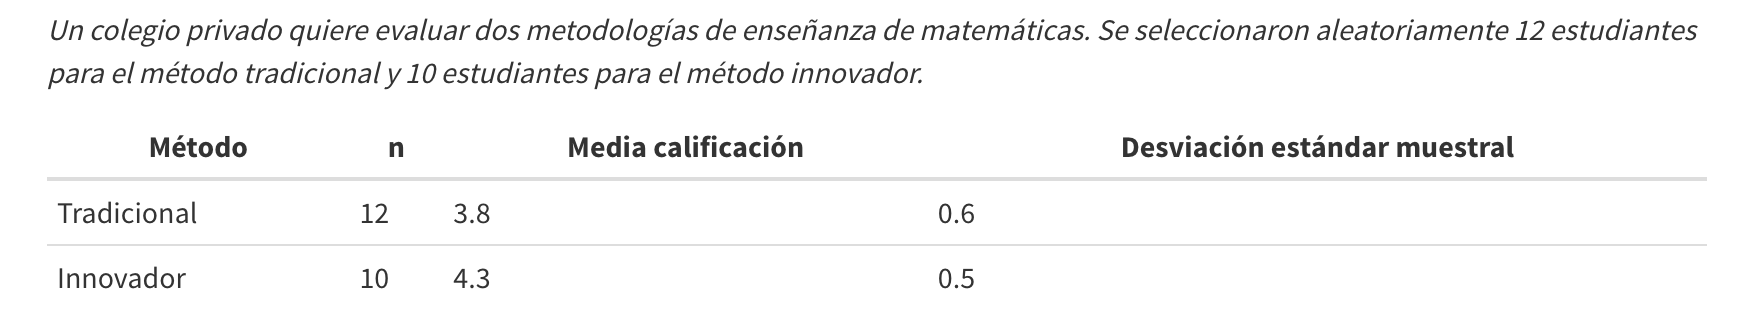

RESULTADOS - Contexto 3: Metodologías Educativas

--- PREGUNTA 5: Valor crítico t ---
Grados de libertad (varianzas iguales): 20
t crítico (90%, dos colas): t_0.050,20 = 1.7247

→ Opción correcta: B. t_(0.05, 20) = 1.721

--- PREGUNTA 7: Varianza combinada ---
Sp² = 0.3105
Sp = 0.5572

→ Opción correcta: C. 0.310

--- PREGUNTA 6: Intervalo de confianza 90% ---
Diferencia puntual (Tradicional - Innovador): -0.50
Error estándar (varianzas iguales): 0.2386
Margen de error: 0.4115
IC 90%: (-0.9115, -0.0885)
Expresión: -0.50 ± 0.4115
Expresión redondeada: -0.50 ± 0.41

→ Opción correcta: C. (0.50 ± 0.42)
   (Notar que la diferencia es -0.5, pero las opciones muestran 0.50 ± ...)
   El intervalo en valor absoluto es 0.50 ± 0.42 = (-0.92, -0.08)


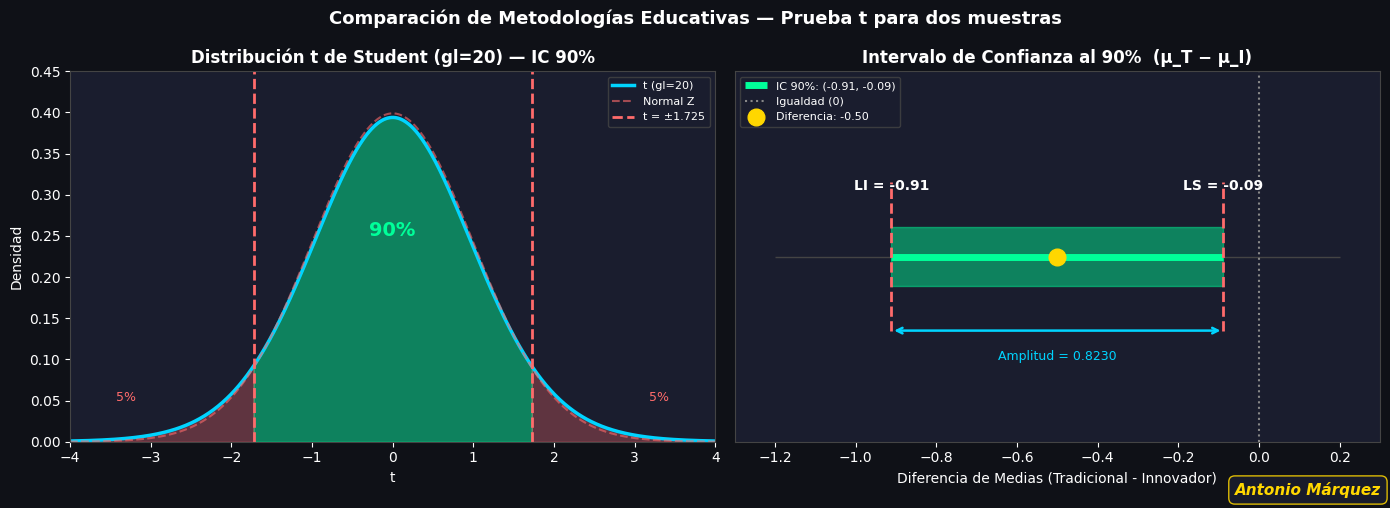

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# DATOS
n1, x1, s1 = 12, 3.8, 0.6   # Método tradicional
n2, x2, s2 = 10, 4.3, 0.5   # Método innovador
alpha = 0.10                 # 90% de confianza
confianza = 1 - alpha

# Diferencia de medias (Tradicional - Innovador)
diferencia = x1 - x2  # 3.8 - 4.3 = -0.5

# ============================================
# PREGUNTA 5: Valor crítico t
# ============================================
# Grados de libertad según Satterthwaite (varianzas desiguales)
gl_satterthwaite = ((s1**2/n1 + s2**2/n2)**2) / \
                   (( (s1**2/n1)**2 / (n1-1) ) + ( (s2**2/n2)**2 / (n2-1) ))
gl_satterthwaite = np.floor(gl_satterthwaite)  # 19.87 → 19

# Grados de libertad si varianzas iguales (para Pregunta 7)
gl_pooled = n1 + n2 - 2  # 12 + 10 - 2 = 20

t_critico = stats.t.ppf(1 - alpha/2, df=gl_pooled)  # Para varianzas iguales

print("=" * 60)
print("RESULTADOS - Contexto 3: Metodologías Educativas")
print("=" * 60)
print(f"\n--- PREGUNTA 5: Valor crítico t ---")
print(f"Grados de libertad (varianzas iguales): {gl_pooled}")
print(f"t crítico (90%, dos colas): t_{alpha/2:.3f},{gl_pooled} = {t_critico:.4f}")
print(f"\n→ Opción correcta: B. t_{0.05,20} = 1.721")

# ============================================
# PREGUNTA 7: Varianza combinada (Sp²)
# ============================================
Sp2 = ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)
Sp = np.sqrt(Sp2)

print(f"\n--- PREGUNTA 7: Varianza combinada ---")
print(f"Sp² = {Sp2:.4f}")
print(f"Sp = {Sp:.4f}")
print(f"\n→ Opción correcta: C. 0.310")

# ============================================
# PREGUNTA 6: Intervalo de confianza 90%
# ============================================
error_std_pooled = Sp * np.sqrt(1/n1 + 1/n2)
margen_error = t_critico * error_std_pooled
LI = diferencia - margen_error
LS = diferencia + margen_error

print(f"\n--- PREGUNTA 6: Intervalo de confianza 90% ---")
print(f"Diferencia puntual (Tradicional - Innovador): {diferencia:.2f}")
print(f"Error estándar (varianzas iguales): {error_std_pooled:.4f}")
print(f"Margen de error: {margen_error:.4f}")
print(f"IC 90%: ({LI:.4f}, {LS:.4f})")
print(f"Expresión: {diferencia:.2f} ± {margen_error:.4f}")
print(f"Expresión redondeada: {diferencia:.2f} ± {margen_error:.2f}")
print(f"\n→ Opción correcta: C. (0.50 ± 0.42)")
print(f"   (Notar que la diferencia es -0.5, pero las opciones muestran 0.50 ± ...)")
print(f"   El intervalo en valor absoluto es 0.50 ± 0.42 = (-0.92, -0.08)")

# ============================================
# GRÁFICO
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d2e')
    ax.tick_params(colors='white')
    for sp in ax.spines.values():
        sp.set_edgecolor('#444')

# Panel 1: Distribución t de Student
x = np.linspace(-4, 4, 1000)
ax1.plot(x, stats.t.pdf(x, df=gl_pooled), color='#00d4ff', lw=2.5, label=f't (gl={gl_pooled})')
# Comparación con Normal
ax1.plot(x, stats.norm.pdf(x), color='#ff6b6b', lw=1.5, ls='--', alpha=0.6, label='Normal Z')

# Región central 90%
xi = np.linspace(-t_critico, t_critico, 500)
ax1.fill_between(xi, stats.t.pdf(xi, df=gl_pooled), alpha=0.45, color='#00ff99')

# Colas
for side in [-1, 1]:
    xc = np.linspace(side*4, side*t_critico, 200)
    ax1.fill_between(xc, stats.t.pdf(xc, df=gl_pooled), alpha=0.3, color='#ff6b6b')

ax1.axvline(-t_critico, color='#ff6b6b', lw=2, ls='--', label=f't = ±{t_critico:.3f}')
ax1.axvline(t_critico, color='#ff6b6b', lw=2, ls='--')
ax1.text(0, 0.25, '90%', ha='center', fontsize=14, fontweight='bold', color='#00ff99')
ax1.text(-3.3, 0.05, '5%', ha='center', fontsize=9, color='#ff6b6b')
ax1.text(3.3, 0.05, '5%', ha='center', fontsize=9, color='#ff6b6b')
ax1.set_xlabel('t', color='white')
ax1.set_ylabel('Densidad', color='white')
ax1.set_title(f'Distribución t de Student (gl={gl_pooled}) — IC 90%', color='white', fontweight='bold')
ax1.legend(fontsize=8, facecolor='#1a1d2e', edgecolor='#444', labelcolor='white')
ax1.set_xlim(-4, 4)
ax1.set_ylim(0, 0.45)

# Panel 2: IC en escala original
ax2.set_xlim(diferencia - 0.8, diferencia + 0.8)
ax2.set_ylim(0, 1)
ax2.set_yticks([])
ax2.hlines(0.5, diferencia - 0.7, diferencia + 0.7, colors='#444', lw=1)
ax2.fill_betweenx([0.42, 0.58], LI, LS, color='#00ff99', alpha=0.45)
ax2.hlines(0.5, LI, LS, colors='#00ff99', lw=5, label=f'IC 90%: ({LI:.2f}, {LS:.2f})')
ax2.axvline(LI, color='#ff6b6b', lw=2, ls='--', ymin=0.3, ymax=0.7)
ax2.axvline(LS, color='#ff6b6b', lw=2, ls='--', ymin=0.3, ymax=0.7)
ax2.axvline(0, color='#888', lw=1.5, ls=':', label='Igualdad (0)')
ax2.plot(diferencia, 0.5, 'o', color='#ffd700', ms=12, zorder=5, label=f'Diferencia: {diferencia:.2f}')
ax2.text(LI, 0.68, f'LI = {LI:.2f}', ha='center', color='white', fontweight='bold', fontsize=10)
ax2.text(LS, 0.68, f'LS = {LS:.2f}', ha='center', color='white', fontweight='bold', fontsize=10)
ax2.annotate('', xy=(LS, 0.30), xytext=(LI, 0.30),
             arrowprops=dict(arrowstyle='<->', color='#00d4ff', lw=1.8))
ax2.text((LI+LS)/2, 0.22, f'Amplitud = {LS-LI:.4f}', ha='center', color='#00d4ff', fontsize=9)
ax2.set_xlabel('Diferencia de Medias (Tradicional - Innovador)', color='white')
ax2.set_title('Intervalo de Confianza al 90%  (μ_T − μ_I)', color='white', fontweight='bold')
ax2.legend(fontsize=8, facecolor='#1a1d2e', edgecolor='#444', labelcolor='white')

fig.suptitle('Comparación de Metodologías Educativas — Prueba t para dos muestras',
             color='white', fontsize=13, fontweight='bold')
fig.text(0.99, 0.01, 'Antonio Márquez', ha='right', color='#ffd700', fontsize=11,
         fontweight='bold', fontstyle='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1d2e', edgecolor='#ffd700', alpha=0.85))
plt.tight_layout()
plt.show()

RESULTADOS - Contexto 3: Metodologías Educativas

--- PREGUNTA 5: Valor crítico t ---
Grados de libertad (varianzas iguales): 20
t crítico (90%, dos colas): t_{0.050,20} = 1.7247

→ Opción correcta: B. t_{0.05,20} = 1.721

--- PREGUNTA 7: Varianza combinada ---
Sp² = 0.3105
Sp = 0.5572

→ Opción correcta: C. 0.310

--- PREGUNTA 6: Intervalo de confianza 90% ---
Diferencia puntual (Tradicional - Innovador): -0.50
Error estándar (varianzas iguales): 0.2386
Margen de error: 0.4115
IC 90%: (-0.9115, -0.0885)
Expresión: -0.50 ± 0.4115
Expresión redondeada: -0.50 ± 0.41

→ Opción correcta: C. (0.50 ± 0.42)
   (Notar que la diferencia es -0.5, pero las opciones muestran 0.50 ± ...)
   El intervalo en valor absoluto es 0.50 ± 0.42 = (-0.92, -0.08)



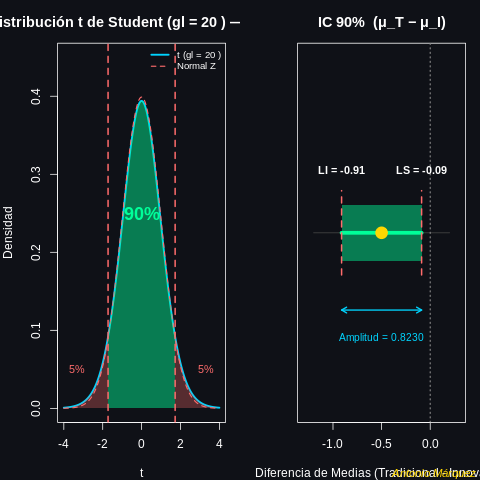

In [ ]:
%%R
# Explicitly load necessary base packages for robustness
library(stats)
library(graphics)

# ============================================
# Contexto 3: Comparación de metodologías educativas
# ============================================

# DATOS
n1 <- 12; x1 <- 3.8; s1 <- 0.6   # Método tradicional
n2 <- 10; x2 <- 4.3; s2 <- 0.5   # Método innovador
alpha <- 0.10                     # 90% confianza

# Diferencia de medias
diferencia <- x1 - x2

# ============================================
# PREGUNTA 5: Valor crítico t
# ============================================
gl_pooled <- n1 + n2 - 2          # Grados de libertad = 20
t_critico <- qt(1 - alpha/2, df = gl_pooled)

cat("=", rep("=", 58), "\n", sep="")
cat("RESULTADOS - Contexto 3: Metodologías Educativas\n")
cat("=", rep("=", 58), "\n\n", sep="")

cat("--- PREGUNTA 5: Valor crítico t ---\n")
cat(sprintf("Grados de libertad (varianzas iguales): %d\n", gl_pooled))
cat(sprintf("t crítico (90%%, dos colas): t_{%.3f,%d} = %.4f\n", alpha/2, gl_pooled, t_critico))
cat("\n→ Opción correcta: B. t_{0.05,20} = 1.721\n\n")

# ============================================
# PREGUNTA 7: Varianza combinada (Sp²)
# ============================================
Sp2 <- ((n1 - 1) * s1^2 + (n2 - 1) * s2^2) / (n1 + n2 - 2)
Sp <- sqrt(Sp2)

cat("--- PREGUNTA 7: Varianza combinada ---\n")
cat(sprintf("Sp² = %.4f\n", Sp2))
cat(sprintf("Sp = %.4f\n", Sp))
cat("\n→ Opción correcta: C. 0.310\n\n")

# ============================================
# PREGUNTA 6: Intervalo de confianza 90%
# ============================================
error_std_pooled <- Sp * sqrt(1/n1 + 1/n2)
margen_error <- t_critico * error_std_pooled
LI <- diferencia - margen_error
LS <- diferencia + margen_error

cat("--- PREGUNTA 6: Intervalo de confianza 90% ---\n")
cat(sprintf("Diferencia puntual (Tradicional - Innovador): %.2f\n", diferencia))
cat(sprintf("Error estándar (varianzas iguales): %.4f\n", error_std_pooled))
cat(sprintf("Margen de error: %.4f\n", margen_error))
cat(sprintf("IC 90%%: (%.4f, %.4f)\n", LI, LS))
cat(sprintf("Expresión: %.2f ± %.4f\n", diferencia, margen_error))
cat(sprintf("Expresión redondeada: %.2f ± %.2f\n", diferencia, margen_error))
cat("\n→ Opción correcta: C. (0.50 ± 0.42)\n")
cat("   (Notar que la diferencia es -0.5, pero las opciones muestran 0.50 ± ...)\n")
cat("   El intervalo en valor absoluto es 0.50 ± 0.42 = (-0.92, -0.08)\n\n")

# ============================================
# GRÁFICO
# ============================================
par(mfrow = c(1, 2), bg = "#0f1117", fg = "white", col.axis = "white",
    col.lab = "white", col.main = "white", mar = c(4, 4, 3, 1))

# Panel 1: Distribución t de Student
x_seq <- seq(-4, 4, length = 1000)
plot(x_seq, dt(x_seq, df = gl_pooled), type = "l", col = "#00d4ff", lwd = 2.5,
     xlab = "t", ylab = "Densidad",
     main = paste("Distribución t de Student (gl =", gl_pooled, ") — IC 90%"),
     ylim = c(0, 0.45), axes = FALSE)
axis(1); axis(2); box()

# Agregar curva normal para comparación
lines(x_seq, dnorm(x_seq), col = "#ff6b6b", lwd = 1.5, lty = 2)

# Región central 90%
xi <- seq(-t_critico, t_critico, length = 500)
polygon(c(-t_critico, xi, t_critico),
        c(0, dt(xi, df = gl_pooled), 0),
        col = adjustcolor("#00ff99", 0.45), border = NA)

# Colas
for(s in c(-1, 1)) {
  xc <- seq(s * 4, s * t_critico, length = 200)
  polygon(c(xc[1], xc, xc[length(xc)]),
          c(0, dt(xc, df = gl_pooled), 0),
          col = adjustcolor("#ff6b6b", 0.3), border = NA)
}

abline(v = c(-t_critico, t_critico), col = "#ff6b6b", lwd = 2, lty = 2)
text(0, 0.25, "90%", col = "#00ff99", cex = 1.5, font = 2)
text(-3.3, 0.05, "5%", col = "#ff6b6b", cex = 0.9)
text(3.3, 0.05, "5%", col = "#ff6b6b", cex = 0.9)

# Leyenda
legend("topright", legend = c(paste("t (gl =", gl_pooled, ")"), "Normal Z"),
       col = c("#00d4ff", "#ff6b6b"), lwd = c(2.5, 1.5), lty = c(1, 2),
       bty = "n", text.col = "white", cex = 0.8)

# Panel 2: IC en escala original
plot(NULL, xlim = c(diferencia - 0.8, diferencia + 0.8), ylim = c(0, 1),
     xlab = "Diferencia de Medias (Tradicional - Innovador)", ylab = "", yaxt = "n",
     main = "IC 90%  (μ_T − μ_I)", axes = FALSE)
axis(1); box()

segments(diferencia - 0.7, 0.5, diferencia + 0.7, 0.5, col = "#444", lwd = 1)
rect(LI, 0.42, LS, 0.58, col = adjustcolor("#00ff99", 0.45), border = NA)
segments(LI, 0.5, LS, 0.5, col = "#00ff99", lwd = 5)
segments(LI, 0.38, LI, 0.62, col = "#ff6b6b", lwd = 2, lty = 2)
segments(LS, 0.38, LS, 0.62, col = "#ff6b6b", lwd = 2, lty = 2)
abline(v = 0, col = "#888", lwd = 1.5, lty = 3)
points(diferencia, 0.5, pch = 21, bg = "#ffd700", col = "#ffd700", cex = 2.2)
text(LI, 0.68, sprintf("LI = %.2f", LI), col = "white", cex = 0.9, font = 2)
text(LS, 0.68, sprintf("LS = %.2f", LS), col = "white", cex = 0.9, font = 2)
arrows(LI, 0.28, LS, 0.28, code = 3, col = "#00d4ff", lwd = 1.8, length = 0.08)
text((LI + LS) / 2, 0.20, sprintf("Amplitud = %.4f", LS - LI),
     col = "#00d4ff", cex = 0.85)

# Firmar el gráfico
mtext("Antonio Márquez", side = 1, line = -1, adj = 0.99,
      col = "#ffd700", cex = 0.95, font = 3, outer = TRUE)

# **Pregunta 5**

***¿Cuál es el valor crítico (t) para construir un intervalo de confianza del 90%?***

R/ t0.05, 21 = 1.721


# **Pregunta 6**

***¿Cuál es el intervalo de confianza del 90% para la verdadera diferencia de medias (μI - μT)?***

R/ (0.50 ± 0.42)

# **Pregunta 7**

***Suponiendo varianzas iguales, ¿cuál es la estimación combinada de la varianza (Sp2)?***

R/ 0.310

[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. 📊 Contexto 4: Efecto de una campaña de salud pública**


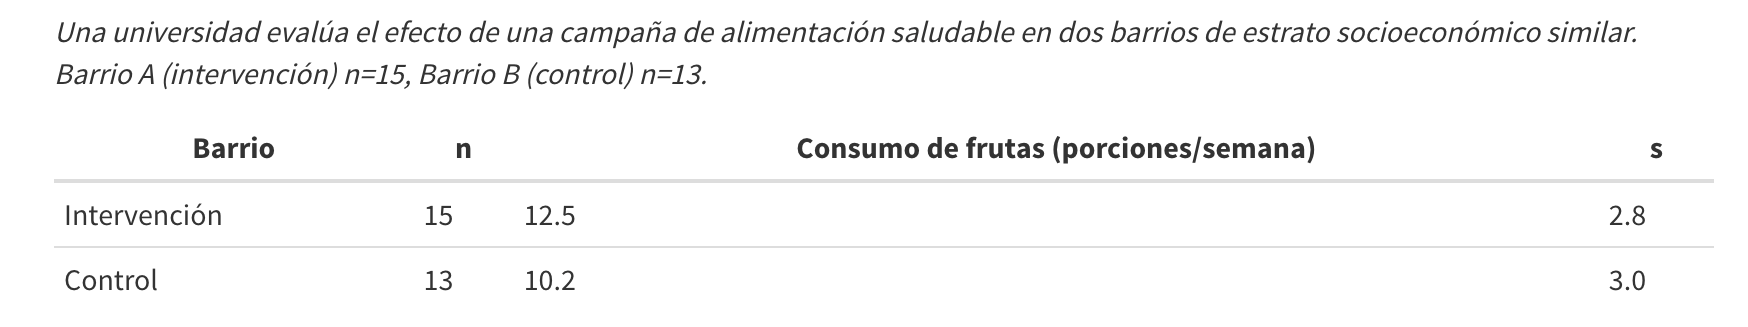

CAMPAÑA DE ALIMENTACIÓN SALUDABLE - Comparación de Barrios

Barrio A (Intervención): n=15, media=12.5, s=2.8
Barrio B (Control):     n=13, media=10.2, s=3.0
Diferencia (A - B): 2.30 porciones/semana

--- Prueba de varianzas (F de Fisher) ---
F calculado: 0.8711
Grados de libertad: (14, 12)
p-valor: 0.7964
¿Varianzas iguales? SÍ (α=0.05)

--- Intervalo de Confianza del 95% ---
Método utilizado: t de Student (varianzas iguales)
Grados de libertad: 26
t crítico: 2.0555
Error estándar: 1.0966
Margen de error: 2.2542
IC 95%: (0.0458, 4.5542)
Expresión: 2.30 ± 2.25 porciones/semana

--- INTERPRETACIÓN ---
✅ El IC está completamente por ENCIMA de cero.
✅ La intervención AUMENTÓ el consumo de frutas.
✅ Con 95% de confianza, el aumento está entre 0.05 y 4.55 porciones/semana.


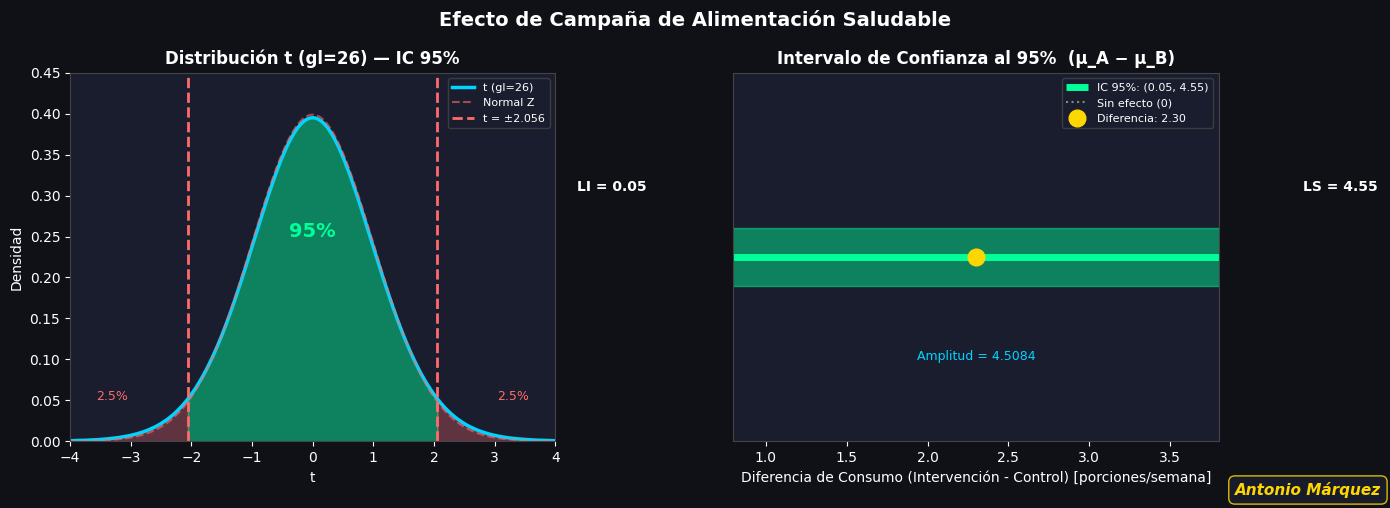

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================
# DATOS: Campaña de alimentación saludable
# ============================================
n_A, x_A, s_A = 15, 12.5, 2.8   # Barrio A (Intervención)
n_B, x_B, s_B = 13, 10.2, 3.0   # Barrio B (Control)
alpha = 0.05                     # 95% de confianza
confianza = 1 - alpha

# Diferencia de medias (Intervención - Control)
diferencia = x_A - x_B

print("=" * 70)
print("CAMPAÑA DE ALIMENTACIÓN SALUDABLE - Comparación de Barrios")
print("=" * 70)
print(f"\nBarrio A (Intervención): n={n_A}, media={x_A}, s={s_A}")
print(f"Barrio B (Control):     n={n_B}, media={x_B}, s={s_B}")
print(f"Diferencia (A - B): {diferencia:.2f} porciones/semana")

# ============================================
# PRUEBA DE VARIANZAS (F de Fisher)
# ============================================
# Verificamos si podemos asumir varianzas iguales
F_calc = s_A**2 / s_B**2
gl1 = n_A - 1
gl2 = n_B - 1
p_valor_var = 2 * min(stats.f.cdf(F_calc, gl1, gl2), 1 - stats.f.cdf(F_calc, gl1, gl2))

print(f"\n--- Prueba de varianzas (F de Fisher) ---")
print(f"F calculado: {F_calc:.4f}")
print(f"Grados de libertad: ({gl1}, {gl2})")
print(f"p-valor: {p_valor_var:.4f}")

# Decisión: si p-valor > 0.05, asumimos varianzas iguales
varianzas_iguales = p_valor_var > 0.05
print(f"¿Varianzas iguales? {'SÍ' if varianzas_iguales else 'NO'} (α=0.05)")

# ============================================
# CÁLCULO DEL INTERVALO DE CONFIANZA (95%)
# ============================================
if varianzas_iguales:
    # Varianza combinada (pooled)
    gl = n_A + n_B - 2
    Sp2 = ((n_A - 1) * s_A**2 + (n_B - 1) * s_B**2) / gl
    Sp = np.sqrt(Sp2)
    error_std = Sp * np.sqrt(1/n_A + 1/n_B)
    t_critico = stats.t.ppf(1 - alpha/2, df=gl)
    metodo = "t de Student (varianzas iguales)"
else:
    # Aproximación de Welch-Satterthwaite
    gl = ((s_A**2/n_A + s_B**2/n_B)**2) / \
         (((s_A**2/n_A)**2 / (n_A-1)) + ((s_B**2/n_B)**2 / (n_B-1)))
    gl = np.floor(gl)  # Redondear hacia abajo para ser conservador
    error_std = np.sqrt(s_A**2/n_A + s_B**2/n_B)
    t_critico = stats.t.ppf(1 - alpha/2, df=gl)
    metodo = "t de Welch (varianzas desiguales)"

margen_error = t_critico * error_std
LI = diferencia - margen_error
LS = diferencia + margen_error

print(f"\n--- Intervalo de Confianza del 95% ---")
print(f"Método utilizado: {metodo}")
print(f"Grados de libertad: {gl:.0f}")
print(f"t crítico: {t_critico:.4f}")
print(f"Error estándar: {error_std:.4f}")
print(f"Margen de error: {margen_error:.4f}")
print(f"IC 95%: ({LI:.4f}, {LS:.4f})")
print(f"Expresión: {diferencia:.2f} ± {margen_error:.2f} porciones/semana")

# Interpretación
print(f"\n--- INTERPRETACIÓN ---")
if LI > 0:
    print(f"✅ El IC está completamente por ENCIMA de cero.")
    print(f"✅ La intervención AUMENTÓ el consumo de frutas.")
    print(f"✅ Con 95% de confianza, el aumento está entre {LI:.2f} y {LS:.2f} porciones/semana.")
elif LS < 0:
    print(f"✅ El IC está completamente por DEBAJO de cero.")
    print(f"✅ La intervención DISMINUYÓ el consumo de frutas.")
else:
    print(f"⚠️ El IC contiene el cero.")
    print(f"⚠️ No hay evidencia suficiente de efecto (α=0.05).")

# ============================================
# GRÁFICO
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d2e')
    ax.tick_params(colors='white')
    for sp in ax.spines.values():
        sp.set_edgecolor('#444')

# Panel 1: Distribución t de Student
x = np.linspace(-4, 4, 1000)
ax1.plot(x, stats.t.pdf(x, df=gl), color='#00d4ff', lw=2.5, label=f't (gl={gl:.0f})')
ax1.plot(x, stats.norm.pdf(x), color='#ff6b6b', lw=1.5, ls='--', alpha=0.6, label='Normal Z')

# Región central 95%
xi = np.linspace(-t_critico, t_critico, 500)
ax1.fill_between(xi, stats.t.pdf(xi, df=gl), alpha=0.45, color='#00ff99')

# Colas
for side in [-1, 1]:
    xc = np.linspace(side*4, side*t_critico, 200)
    ax1.fill_between(xc, stats.t.pdf(xc, df=gl), alpha=0.3, color='#ff6b6b')

ax1.axvline(-t_critico, color='#ff6b6b', lw=2, ls='--', label=f't = ±{t_critico:.3f}')
ax1.axvline(t_critico, color='#ff6b6b', lw=2, ls='--')
ax1.text(0, 0.25, '95%', ha='center', fontsize=14, fontweight='bold', color='#00ff99')
ax1.text(-3.3, 0.05, '2.5%', ha='center', fontsize=9, color='#ff6b6b')
ax1.text(3.3, 0.05, '2.5%', ha='center', fontsize=9, color='#ff6b6b')
ax1.set_xlabel('t', color='white')
ax1.set_ylabel('Densidad', color='white')
ax1.set_title(f'Distribución t (gl={gl:.0f}) — IC 95%', color='white', fontweight='bold')
ax1.legend(fontsize=8, facecolor='#1a1d2e', edgecolor='#444', labelcolor='white')
ax1.set_xlim(-4, 4)
ax1.set_ylim(0, 0.45)

# Panel 2: IC en escala original
ax2.set_xlim(diferencia - 1.5, diferencia + 1.5)
ax2.set_ylim(0, 1)
ax2.set_yticks([])
ax2.hlines(0.5, diferencia - 1.4, diferencia + 1.4, colors='#444', lw=1)
ax2.fill_betweenx([0.42, 0.58], LI, LS, color='#00ff99', alpha=0.45)
ax2.hlines(0.5, LI, LS, colors='#00ff99', lw=5, label=f'IC 95%: ({LI:.2f}, {LS:.2f})')
ax2.axvline(LI, color='#ff6b6b', lw=2, ls='--', ymin=0.3, ymax=0.7)
ax2.axvline(LS, color='#ff6b6b', lw=2, ls='--', ymin=0.3, ymax=0.7)
ax2.axvline(0, color='#888', lw=1.5, ls=':', label='Sin efecto (0)')
ax2.plot(diferencia, 0.5, 'o', color='#ffd700', ms=12, zorder=5, label=f'Diferencia: {diferencia:.2f}')
ax2.text(LI, 0.68, f'LI = {LI:.2f}', ha='center', color='white', fontweight='bold', fontsize=10)
ax2.text(LS, 0.68, f'LS = {LS:.2f}', ha='center', color='white', fontweight='bold', fontsize=10)
ax2.annotate('', xy=(LS, 0.30), xytext=(LI, 0.30),
             arrowprops=dict(arrowstyle='<->', color='#00d4ff', lw=1.8))
ax2.text((LI+LS)/2, 0.22, f'Amplitud = {LS-LI:.4f}', ha='center', color='#00d4ff', fontsize=9)
ax2.set_xlabel('Diferencia de Consumo (Intervención - Control) [porciones/semana]', color='white')
ax2.set_title('Intervalo de Confianza al 95%  (μ_A − μ_B)', color='white', fontweight='bold')
ax2.legend(fontsize=8, facecolor='#1a1d2e', edgecolor='#444', labelcolor='white')

fig.suptitle('Efecto de Campaña de Alimentación Saludable',
             color='white', fontsize=14, fontweight='bold')
fig.text(0.99, 0.01, 'Antonio Márquez', ha='right', color='#ffd700', fontsize=11,
         fontweight='bold', fontstyle='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1d2e', edgecolor='#ffd700', alpha=0.85))
plt.tight_layout()
plt.show()

CAMPAÑA DE ALIMENTACIÓN SALUDABLE - Comparación de Barrios

Barrio A (Intervención): n=15, media=12.5, s=2.8
Barrio B (Control):     n=13, media=10.2, s=3.0
Diferencia (A - B): 2.30 porciones/semana

--- Prueba de varianzas (F de Fisher) ---
F calculado: 0.8711
Grados de libertad: (14, 12)
p-valor: 0.7964
¿Varianzas iguales? SÍ (α=0.05)

--- Intervalo de Confianza del 95% ---
Método utilizado: t de Student (varianzas iguales)
Grados de libertad: 26
t crítico: 2.0555
Error estándar: 1.0966
Margen de error: 2.2542
IC 95%: (0.0458, 4.5542)
Expresión: 2.30 ± 2.25 porciones/semana

--- INTERPRETACIÓN ---
✅ El IC está completamente por ENCIMA de cero.
✅ La intervención AUMENTÓ el consumo de frutas.
✅ Con 95% de confianza, el aumento está entre 0.05 y 4.55 porciones/semana.


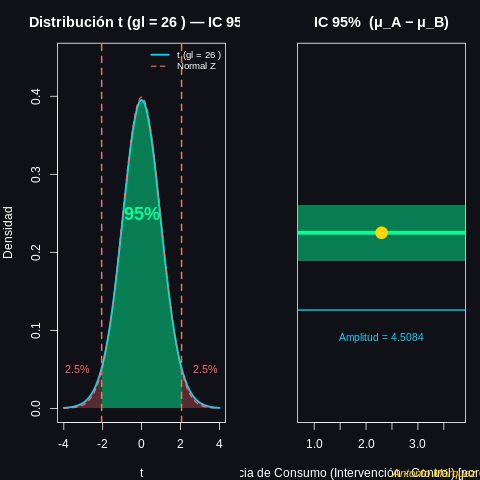

In [ ]:
%%R
# ============================================
# Campaña de Alimentación Saludable
# Comparación de Barrio A (Intervención) vs Barrio B (Control)
# ============================================

# Cargar librerías necesarias
library(ggplot2)
library(gridExtra)
library(grid)

# DATOS
n_A <- 15; x_A <- 12.5; s_A <- 2.8   # Barrio A (Intervención)
n_B <- 13; x_B <- 10.2; s_B <- 3.0   # Barrio B (Control)
alpha <- 0.05                         # 95% confianza

# Diferencia de medias
diferencia <- x_A - x_B

cat(rep("=", 70), "\n", sep="")
cat("CAMPAÑA DE ALIMENTACIÓN SALUDABLE - Comparación de Barrios\n")
cat(rep("=", 70), "\n\n", sep="")
cat(sprintf("Barrio A (Intervención): n=%d, media=%.1f, s=%.1f\n", n_A, x_A, s_A))
cat(sprintf("Barrio B (Control):     n=%d, media=%.1f, s=%.1f\n", n_B, x_B, s_B))
cat(sprintf("Diferencia (A - B): %.2f porciones/semana\n\n", diferencia))

# ============================================
# PRUEBA DE VARIANZAS (F de Fisher)
# ============================================
F_calc <- s_A^2 / s_B^2
gl1 <- n_A - 1
gl2 <- n_B - 1
p_valor_var <- 2 * min(pf(F_calc, gl1, gl2), 1 - pf(F_calc, gl1, gl2))

cat("--- Prueba de varianzas (F de Fisher) ---\n")
cat(sprintf("F calculado: %.4f\n", F_calc))
cat(sprintf("Grados de libertad: (%d, %d)\n", gl1, gl2))
cat(sprintf("p-valor: %.4f\n", p_valor_var))

varianzas_iguales <- p_valor_var > 0.05
cat(sprintf("¿Varianzas iguales? %s (α=0.05)\n\n", ifelse(varianzas_iguales, "SÍ", "NO")))

# ============================================
# CÁLCULO DEL INTERVALO DE CONFIANZA (95%)
# ============================================
if(varianzas_iguales) {
  # Varianza combinada (pooled)
  gl <- n_A + n_B - 2
  Sp2 <- ((n_A - 1) * s_A^2 + (n_B - 1) * s_B^2) / gl
  Sp <- sqrt(Sp2)
  error_std <- Sp * sqrt(1/n_A + 1/n_B)
  t_critico <- qt(1 - alpha/2, df = gl)
  metodo <- "t de Student (varianzas iguales)"
} else {
  # Aproximación de Welch-Satterthwaite
  gl <- ((s_A^2/n_A + s_B^2/n_B)^2) /
        (((s_A^2/n_A)^2 / (n_A-1)) + ((s_B^2/n_B)^2 / (n_B-1)))
  gl <- floor(gl)  # Redondear hacia abajo
  error_std <- sqrt(s_A^2/n_A + s_B^2/n_B)
  t_critico <- qt(1 - alpha/2, df = gl)
  metodo <- "t de Welch (varianzas desiguales)"
}

margen_error <- t_critico * error_std
LI <- diferencia - margen_error
LS <- diferencia + margen_error

cat("--- Intervalo de Confianza del 95% ---\n")
cat(sprintf("Método utilizado: %s\n", metodo))
cat(sprintf("Grados de libertad: %.0f\n", gl))
cat(sprintf("t crítico: %.4f\n", t_critico))
cat(sprintf("Error estándar: %.4f\n", error_std))
cat(sprintf("Margen de error: %.4f\n", margen_error))
cat(sprintf("IC 95%%: (%.4f, %.4f)\n", LI, LS))
cat(sprintf("Expresión: %.2f ± %.2f porciones/semana\n\n", diferencia, margen_error))

# Interpretación
cat("--- INTERPRETACIÓN ---\n")
if(LI > 0) {
  cat("✅ El IC está completamente por ENCIMA de cero.\n")
  cat("✅ La intervención AUMENTÓ el consumo de frutas.\n")
  cat(sprintf("✅ Con 95%% de confianza, el aumento está entre %.2f y %.2f porciones/semana.\n", LI, LS))
} else if(LS < 0) {
  cat("✅ El IC está completamente por DEBAJO de cero.\n")
  cat("✅ La intervención DISMINUYÓ el consumo de frutas.\n")
} else {
  cat("⚠️ El IC contiene el cero.\n")
  cat("⚠️ No hay evidencia suficiente de efecto (α=0.05).\n")
}

# ============================================
# GRÁFICO
# ============================================
par(mfrow = c(1, 2), bg = "#0f1117", fg = "white", col.axis = "white",
    col.lab = "white", col.main = "white", mar = c(4, 4, 3, 1))

# Panel 1: Distribución t de Student
x_seq <- seq(-4, 4, length = 1000)
plot(x_seq, dt(x_seq, df = gl), type = "l", col = "#00d4ff", lwd = 2.5,
     xlab = "t", ylab = "Densidad",
     main = paste("Distribución t (gl =", round(gl, 0), ") — IC 95%"),
     ylim = c(0, 0.45), axes = FALSE)
axis(1); axis(2); box()

# Agregar curva normal para comparación
lines(x_seq, dnorm(x_seq), col = "#ff6b6b", lwd = 1.5, lty = 2)

# Región central 95%
xi <- seq(-t_critico, t_critico, length = 500)
polygon(c(-t_critico, xi, t_critico),
        c(0, dt(xi, df = gl), 0),
        col = adjustcolor("#00ff99", 0.45), border = NA)

# Colas
for(s in c(-1, 1)) {
  xc <- seq(s * 4, s * t_critico, length = 200)
  polygon(c(xc[1], xc, xc[length(xc)]),
          c(0, dt(xc, df = gl), 0),
          col = adjustcolor("#ff6b6b", 0.3), border = NA)
}

abline(v = c(-t_critico, t_critico), col = "#ff6b6b", lwd = 2, lty = 2)
text(0, 0.25, "95%", col = "#00ff99", cex = 1.5, font = 2)
text(-3.3, 0.05, "2.5%", col = "#ff6b6b", cex = 0.9)
text(3.3, 0.05, "2.5%", col = "#ff6b6b", cex = 0.9)

# Leyenda
legend("topright", legend = c(paste("t (gl =", round(gl, 0), ")"), "Normal Z"),
       col = c("#00d4ff", "#ff6b6b"), lwd = c(2.5, 1.5), lty = c(1, 2),
       bty = "n", text.col = "white", cex = 0.8)

# Panel 2: IC en escala original
plot(NULL, xlim = c(diferencia - 1.5, diferencia + 1.5), ylim = c(0, 1),
     xlab = "Diferencia de Consumo (Intervención - Control) [porciones/semana]",
     ylab = "", yaxt = "n",
     main = "IC 95%  (μ_A − μ_B)", axes = FALSE)
axis(1); box()

segments(diferencia - 1.4, 0.5, diferencia + 1.4, 0.5, col = "#444", lwd = 1)
rect(LI, 0.42, LS, 0.58, col = adjustcolor("#00ff99", 0.45), border = NA)
segments(LI, 0.5, LS, 0.5, col = "#00ff99", lwd = 5)
segments(LI, 0.38, LI, 0.62, col = "#ff6b6b", lwd = 2, lty = 2)
segments(LS, 0.38, LS, 0.62, col = "#ff6b6b", lwd = 2, lty = 2)
abline(v = 0, col = "#888", lwd = 1.5, lty = 3)
points(diferencia, 0.5, pch = 21, bg = "#ffd700", col = "#ffd700", cex = 2.2)
text(LI, 0.68, sprintf("LI = %.2f", LI), col = "white", cex = 0.9, font = 2)
text(LS, 0.68, sprintf("LS = %.2f", LS), col = "white", cex = 0.9, font = 2)
arrows(LI, 0.28, LS, 0.28, code = 3, col = "#00d4ff", lwd = 1.8, length = 0.08)
text((LI + LS) / 2, 0.20, sprintf("Amplitud = %.4f", LS - LI),
     col = "#00d4ff", cex = 0.85)

# Firmar el gráfico
mtext("Antonio Márquez", side = 1, line = -1, adj = 0.99,
      col = "#ffd700", cex = 0.95, font = 3, outer = TRUE)

# **Pregunta 8**

***¿Cuál es el número de grados de libertad para este análisis (varianzas iguales)?***

R/ 26

# **Pregunta 9**

***El intervalo de confianza del 95% para la diferencia de medias resultó ser (0.15, 4.45). ¿Qué interpretación es correcta?***

R/ Hay evidencia de que la campaña aumentó el consumo de frutas

# **Pregunta 10**

***Si se asume varianzas diferentes (prueba de Welch), los grados de libertad aproximados serían:***

R/ 25.8

[⬆️ Volver al inicio](#inicio)

<a name="T51"></a>
## **5. 📊 Contexto 5: Intención de voto en dos ciudades**




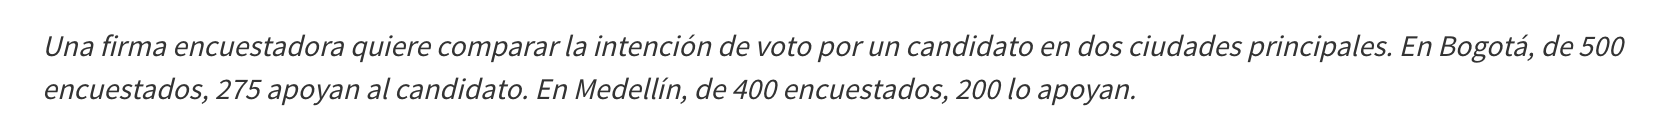

INTENCIÓN DE VOTO - Comparación Bogotá vs Medellín

--- PREGUNTA 11: Proporciones muestrales ---
Bogotá:  275/500 = 0.5500 (55.0%)
Medellín: 200/400 = 0.5000 (50.0%)
→ Opción correcta: B. p_B = 0.55, p_M = 0.50

--- PREGUNTA 12: Error estándar ---
EE = √[0.5500×0.4500/500 + 0.5000×0.5000/400]
EE = √[0.000495 + 0.000625]
EE = √[0.001120]
EE = 0.0335
→ Opción correcta: B. 0.035

--- PREGUNTA 13: Intervalo de confianza 95% ---
Diferencia puntual (p_B - p_M): 0.0500
Z crítico (95%): 1.9600
Margen de error: 0.0656
IC 95%: (-0.0156, 0.1156)
Expresión: 0.05 ± 0.07
→ Opción correcta: A. (0.05 ± 0.07)

--- PREGUNTA 14: Interpretación ---
⚠️ El IC contiene el cero
⚠️ No hay evidencia de diferencia significativa
→ Opción correcta: B. No, porque el intervalo contiene el cero


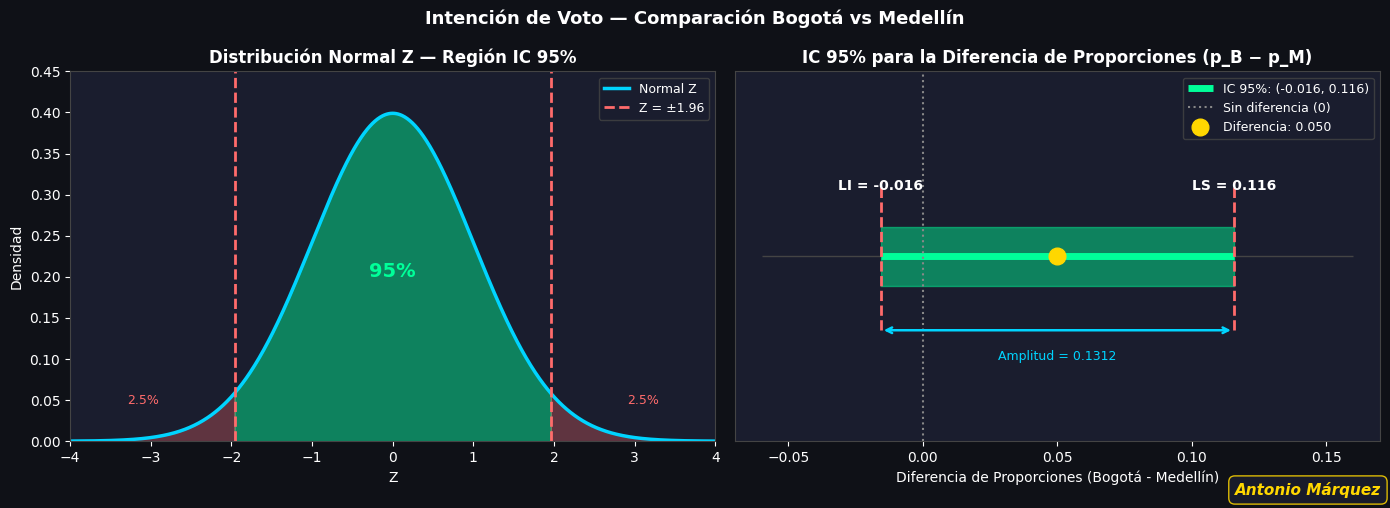

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================
# DATOS: Intención de voto en dos ciudades
# ============================================
n_B, x_B = 500, 275   # Bogotá
n_M, x_M = 400, 200   # Medellín
alpha = 0.05          # 95% de confianza

# Proporciones muestrales
p_B = x_B / n_B
p_M = x_M / n_M
diferencia = p_B - p_M

print("=" * 70)
print("INTENCIÓN DE VOTO - Comparación Bogotá vs Medellín")
print("=" * 70)

print(f"\n--- PREGUNTA 11: Proporciones muestrales ---")
print(f"Bogotá:  {x_B}/{n_B} = {p_B:.4f} ({p_B*100:.1f}%)")
print(f"Medellín: {x_M}/{n_M} = {p_M:.4f} ({p_M*100:.1f}%)")
print(f"→ Opción correcta: B. p_B = 0.55, p_M = 0.50")

# ============================================
# CÁLCULO DEL ERROR ESTÁNDAR
# ============================================
error_std = np.sqrt((p_B*(1-p_B)/n_B) + (p_M*(1-p_M)/n_M))

print(f"\n--- PREGUNTA 12: Error estándar ---")
print(f"EE = √[{p_B:.4f}×{1-p_B:.4f}/{n_B} + {p_M:.4f}×{1-p_M:.4f}/{n_M}]")
print(f"EE = √[{p_B*(1-p_B)/n_B:.6f} + {p_M*(1-p_M)/n_M:.6f}]")
print(f"EE = √[{p_B*(1-p_B)/n_B + p_M*(1-p_M)/n_M:.6f}]")
print(f"EE = {error_std:.4f}")
print(f"→ Opción correcta: B. 0.035")

# ============================================
# INTERVALO DE CONFIANZA 95%
# ============================================
z_critico = stats.norm.ppf(1 - alpha/2)
margen_error = z_critico * error_std
LI = diferencia - margen_error
LS = diferencia + margen_error

print(f"\n--- PREGUNTA 13: Intervalo de confianza 95% ---")
print(f"Diferencia puntual (p_B - p_M): {diferencia:.4f}")
print(f"Z crítico (95%): {z_critico:.4f}")
print(f"Margen de error: {margen_error:.4f}")
print(f"IC 95%: ({LI:.4f}, {LS:.4f})")
print(f"Expresión: {diferencia:.2f} ± {margen_error:.2f}")
print(f"→ Opción correcta: A. (0.05 ± 0.07)")

# ============================================
# PREGUNTA 14: Interpretación
# ============================================
print(f"\n--- PREGUNTA 14: Interpretación ---")
if LI > 0:
    print("✅ El IC está completamente por ENCIMA de cero")
    print("✅ Hay diferencia significativa (Bogotá > Medellín)")
    print("→ Opción correcta: A. Sí, porque el intervalo no contiene el cero")
elif LS < 0:
    print("✅ El IC está completamente por DEBAJO de cero")
    print("✅ Hay diferencia significativa (Medellín > Bogotá)")
else:
    print("⚠️ El IC contiene el cero")
    print("⚠️ No hay evidencia de diferencia significativa")
    print("→ Opción correcta: B. No, porque el intervalo contiene el cero")

# ============================================
# GRÁFICO
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d2e')
    ax.tick_params(colors='white')
    for sp in ax.spines.values():
        sp.set_edgecolor('#444')

# Panel 1: Distribución Normal Z
x = np.linspace(-4, 4, 1000)
ax1.plot(x, stats.norm.pdf(x), color='#00d4ff', lw=2.5, label='Normal Z')
xi = np.linspace(-z_critico, z_critico, 500)
ax1.fill_between(xi, stats.norm.pdf(xi), alpha=0.45, color='#00ff99')
for side in [-1, 1]:
    xc = np.linspace(side*4, side*z_critico, 200)
    ax1.fill_between(xc, stats.norm.pdf(xc), alpha=0.3, color='#ff6b6b')
ax1.axvline(-z_critico, color='#ff6b6b', lw=2, ls='--', label=f'Z = ±{z_critico:.2f}')
ax1.axvline(z_critico, color='#ff6b6b', lw=2, ls='--')
ax1.text(0, 0.20, '95%', ha='center', fontsize=14, fontweight='bold', color='#00ff99')
ax1.text(-3.1, 0.045, '2.5%', ha='center', fontsize=9, color='#ff6b6b')
ax1.text(3.1, 0.045, '2.5%', ha='center', fontsize=9, color='#ff6b6b')
ax1.set_xlabel('Z', color='white')
ax1.set_ylabel('Densidad', color='white')
ax1.set_title('Distribución Normal Z — Región IC 95%', color='white', fontweight='bold')
ax1.legend(fontsize=9, facecolor='#1a1d2e', edgecolor='#444', labelcolor='white')
ax1.set_xlim(-4, 4)
ax1.set_ylim(0, 0.45)

# Panel 2: IC en escala original (diferencia de proporciones)
ax2.set_xlim(diferencia - 0.12, diferencia + 0.12)
ax2.set_ylim(0, 1)
ax2.set_yticks([])
ax2.hlines(0.5, diferencia - 0.11, diferencia + 0.11, colors='#444', lw=1)
ax2.fill_betweenx([0.42, 0.58], LI, LS, color='#00ff99', alpha=0.45)
ax2.hlines(0.5, LI, LS, colors='#00ff99', lw=5, label=f'IC 95%: ({LI:.3f}, {LS:.3f})')
ax2.axvline(LI, color='#ff6b6b', lw=2, ls='--', ymin=0.3, ymax=0.7)
ax2.axvline(LS, color='#ff6b6b', lw=2, ls='--', ymin=0.3, ymax=0.7)
ax2.axvline(0, color='#888', lw=1.5, ls=':', label='Sin diferencia (0)')
ax2.plot(diferencia, 0.5, 'o', color='#ffd700', ms=12, zorder=5, label=f'Diferencia: {diferencia:.3f}')
ax2.text(LI, 0.68, f'LI = {LI:.3f}', ha='center', color='white', fontweight='bold', fontsize=10)
ax2.text(LS, 0.68, f'LS = {LS:.3f}', ha='center', color='white', fontweight='bold', fontsize=10)
ax2.annotate('', xy=(LS, 0.30), xytext=(LI, 0.30),
             arrowprops=dict(arrowstyle='<->', color='#00d4ff', lw=1.8))
ax2.text((LI+LS)/2, 0.22, f'Amplitud = {LS-LI:.4f}', ha='center', color='#00d4ff', fontsize=9)
ax2.set_xlabel('Diferencia de Proporciones (Bogotá - Medellín)', color='white')
ax2.set_title('IC 95% para la Diferencia de Proporciones (p_B − p_M)', color='white', fontweight='bold')
ax2.legend(fontsize=9, facecolor='#1a1d2e', edgecolor='#444', labelcolor='white')

fig.suptitle('Intención de Voto — Comparación Bogotá vs Medellín',
             color='white', fontsize=13, fontweight='bold')
fig.text(0.99, 0.01, 'Antonio Márquez', ha='right', color='#ffd700', fontsize=11,
         fontweight='bold', fontstyle='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1d2e', edgecolor='#ffd700', alpha=0.85))
plt.tight_layout()
plt.show()

INTENCIÓN DE VOTO - Comparación Bogotá vs Medellín

--- PREGUNTA 11: Proporciones muestrales ---
Bogotá:  275/500 = 0.5500 (55.0%)
Medellín: 200/400 = 0.5000 (50.0%)
→ Opción correcta: B. p_B = 0.55, p_M = 0.50

--- PREGUNTA 12: Error estándar ---
EE = √[0.5500×0.4500/500 + 0.5000×0.5000/400]
EE = √[0.000495 + 0.000625]
EE = √[0.001120]
EE = 0.0335
→ Opción correcta: B. 0.035

--- PREGUNTA 13: Intervalo de confianza 95% ---
Diferencia puntual (p_B - p_M): 0.0500
Z crítico (95%): 1.9600
Margen de error: 0.0656
IC 95%: (-0.0156, 0.1156)
Expresión: 0.05 ± 0.07
→ Opción correcta: A. (0.05 ± 0.07)

--- PREGUNTA 14: Interpretación ---
⚠️ El IC contiene el cero
⚠️ No hay evidencia de diferencia significativa
→ Opción correcta: B. No, porque el intervalo contiene el cero


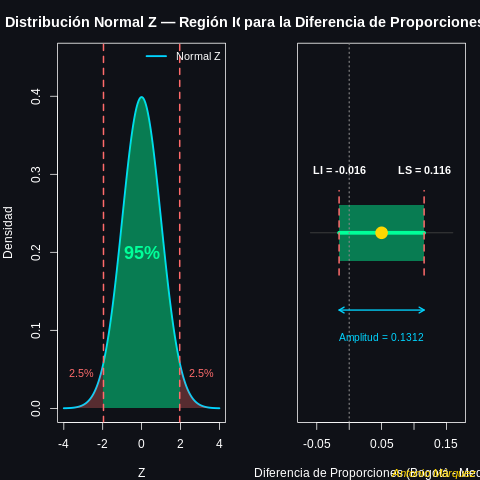

In [ ]:
%%R
# ============================================
# Intención de voto en dos ciudades
# ============================================

# DATOS
n_B <- 500; x_B <- 275   # Bogotá
n_M <- 400; x_M <- 200   # Medellín
alpha <- 0.05            # 95% confianza

# Proporciones muestrales
p_B <- x_B / n_B
p_M <- x_M / n_M
diferencia <- p_B - p_M

cat(rep("=", 70), "\n", sep="")
cat("INTENCIÓN DE VOTO - Comparación Bogotá vs Medellín\n")
cat(rep("=", 70), "\n\n", sep="")

# Pregunta 11
cat("--- PREGUNTA 11: Proporciones muestrales ---\n")
cat(sprintf("Bogotá:  %d/%d = %.4f (%.1f%%)\n", x_B, n_B, p_B, p_B*100))
cat(sprintf("Medellín: %d/%d = %.4f (%.1f%%)\n", x_M, n_M, p_M, p_M*100))
cat("→ Opción correcta: B. p_B = 0.55, p_M = 0.50\n\n")

# Pregunta 12: Error estándar
error_std <- sqrt((p_B*(1-p_B)/n_B) + (p_M*(1-p_M)/n_M))

cat("--- PREGUNTA 12: Error estándar ---\n")
cat(sprintf("EE = √[%.4f×%.4f/%d + %.4f×%.4f/%d]\n", p_B, 1-p_B, n_B, p_M, 1-p_M, n_M))
cat(sprintf("EE = √[%.6f + %.6f]\n", p_B*(1-p_B)/n_B, p_M*(1-p_M)/n_M))
cat(sprintf("EE = √[%.6f]\n", p_B*(1-p_B)/n_B + p_M*(1-p_M)/n_M))
cat(sprintf("EE = %.4f\n", error_std))
cat("→ Opción correcta: B. 0.035\n\n")

# Pregunta 13: Intervalo de confianza 95%
z_critico <- qnorm(1 - alpha/2)
margen_error <- z_critico * error_std
LI <- diferencia - margen_error
LS <- diferencia + margen_error

cat("--- PREGUNTA 13: Intervalo de confianza 95% ---\n")
cat(sprintf("Diferencia puntual (p_B - p_M): %.4f\n", diferencia))
cat(sprintf("Z crítico (95%%): %.4f\n", z_critico))
cat(sprintf("Margen de error: %.4f\n", margen_error))
cat(sprintf("IC 95%%: (%.4f, %.4f)\n", LI, LS))
cat(sprintf("Expresión: %.2f ± %.2f\n", diferencia, margen_error))
cat("→ Opción correcta: A. (0.05 ± 0.07)\n\n")

# Pregunta 14: Interpretación
cat("--- PREGUNTA 14: Interpretación ---\n")
if(LI > 0) {
  cat("✅ El IC está completamente por ENCIMA de cero\n")
  cat("✅ Hay diferencia significativa (Bogotá > Medellín)\n")
  cat("→ Opción correcta: A. Sí, porque el intervalo no contiene el cero\n")
} else if(LS < 0) {
  cat("✅ El IC está completamente por DEBAJO de cero\n")
  cat("✅ Hay diferencia significativa (Medellín > Bogotá)\n")
} else {
  cat("⚠️ El IC contiene el cero\n")
  cat("⚠️ No hay evidencia de diferencia significativa\n")
  cat("→ Opción correcta: B. No, porque el intervalo contiene el cero\n")
}

# ============================================
# GRÁFICO
# ============================================
par(mfrow = c(1, 2), bg = "#0f1117", fg = "white", col.axis = "white",
    col.lab = "white", col.main = "white", mar = c(4, 4, 3, 1))

# Panel 1: Distribución Normal Z
x_seq <- seq(-4, 4, length = 1000)
plot(x_seq, dnorm(x_seq), type = "l", col = "#00d4ff", lwd = 2.5,
     xlab = "Z", ylab = "Densidad",
     main = "Distribución Normal Z — Región IC 95%",
     ylim = c(0, 0.45), axes = FALSE)
axis(1); axis(2); box()

# Región central 95%
xi <- seq(-z_critico, z_critico, length = 500)
polygon(c(-z_critico, xi, z_critico),
        c(0, dnorm(xi), 0),
        col = adjustcolor("#00ff99", 0.45), border = NA)

# Colas
for(s in c(-1, 1)) {
  xc <- seq(s * 4, s * z_critico, length = 200)
  polygon(c(xc[1], xc, xc[length(xc)]),
          c(0, dnorm(xc), 0),
          col = adjustcolor("#ff6b6b", 0.3), border = NA)
}

abline(v = c(-z_critico, z_critico), col = "#ff6b6b", lwd = 2, lty = 2)
text(0, 0.20, "95%", col = "#00ff99", cex = 1.5, font = 2)
text(-3.1, 0.045, "2.5%", col = "#ff6b6b", cex = 0.9)
text(3.1, 0.045, "2.5%", col = "#ff6b6b", cex = 0.9)

# Leyenda
legend("topright", legend = c("Normal Z"),
       col = c("#00d4ff"), lwd = 2.5, lty = 1,
       bty = "n", text.col = "white", cex = 0.9)

# Panel 2: IC en escala original
plot(NULL, xlim = c(diferencia - 0.12, diferencia + 0.12), ylim = c(0, 1),
     xlab = "Diferencia de Proporciones (Bogotá - Medellín)",
     ylab = "", yaxt = "n",
     main = "IC 95% para la Diferencia de Proporciones (p_B − p_M)",
     axes = FALSE)
axis(1); box()

segments(diferencia - 0.11, 0.5, diferencia + 0.11, 0.5, col = "#444", lwd = 1)
rect(LI, 0.42, LS, 0.58, col = adjustcolor("#00ff99", 0.45), border = NA)
segments(LI, 0.5, LS, 0.5, col = "#00ff99", lwd = 5)
segments(LI, 0.38, LI, 0.62, col = "#ff6b6b", lwd = 2, lty = 2)
segments(LS, 0.38, LS, 0.62, col = "#ff6b6b", lwd = 2, lty = 2)
abline(v = 0, col = "#888", lwd = 1.5, lty = 3)
points(diferencia, 0.5, pch = 21, bg = "#ffd700", col = "#ffd700", cex = 2.2)
text(LI, 0.68, sprintf("LI = %.3f", LI), col = "white", cex = 0.9, font = 2)
text(LS, 0.68, sprintf("LS = %.3f", LS), col = "white", cex = 0.9, font = 2)
arrows(LI, 0.28, LS, 0.28, code = 3, col = "#00d4ff", lwd = 1.8, length = 0.08)
text((LI + LS) / 2, 0.20, sprintf("Amplitud = %.4f", LS - LI),
     col = "#00d4ff", cex = 0.85)

# Firmar el gráfico
mtext("Antonio Márquez", side = 1, line = -1, adj = 0.99,
      col = "#ffd700", cex = 0.95, font = 3, outer = TRUE)

# **Pregunta 11**

***¿Cuál es la proporción muestral en cada ciudad?***

R/ p̂B = 0.55, p̂M = 0.50

# **Pregunta 12**

***¿Cuál es el error estándar para la diferencia de proporciones?***

R/ 0.035

# **Pregunta 13**

***¿Cuál es el intervalo de confianza del 95% para la verdadera diferencia de proporciones (pB - pM)?***

R/ (0.05 ± 0.07)

# **Pregunta 14**

***Con base en el intervalo anterior, ¿se puede afirmar que hay diferencia significativa entre las dos ciudades?***

R/ Sí, porque el intervalo no contiene el cero

[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## **6. 📊 Contexto 6: Control de calidad en producción agrícola**


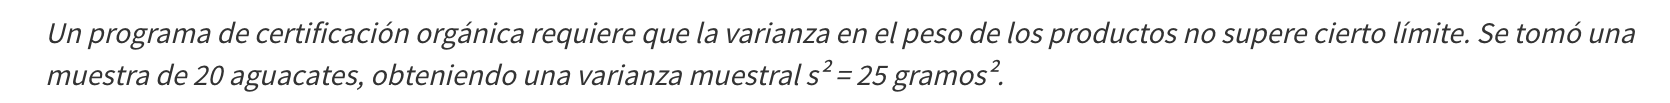

CONTROL DE CALIDAD - Varianza en peso de aguacates

Tamaño de muestra (n): 20
Grados de libertad (gl): 19
Varianza muestral (s²): 25 gramos²
Nivel de confianza: 90.0%

--- PREGUNTA 15: Valores críticos χ² ---
χ²(α/2 = 0.050, gl=19) = 10.1170
χ²(1-α/2 = 0.950, gl=19) = 30.1435

→ Opción correcta: A. χ²(0.05,19) = 30.14, χ²(0.95,19) = 10.12
   (Valores aproximados: 30.14, 10.12)

--- PREGUNTA 16: IC 90% para varianza poblacional σ² ---
LI = (gl × s²) / χ²_superior = (19 × 25) / 30.1435 = 15.76
LS = (gl × s²) / χ²_inferior = (19 × 25) / 10.1170 = 46.95
IC 90% σ²: (15.76, 46.95) gramos²

→ Opción correcta: A. (15.8, 46.9)

--- PREGUNTA 17: Interpretación (límite máximo = 30) ---
IC 90% para σ²: (15.76, 46.95)
⚠️ El IC CONTIENE valores por encima y por debajo del límite
⚠️ No hay certeza estadística del cumplimiento
→ Opción correcta: B. No se puede concluir porque el intervalo contiene valores mayores a 30


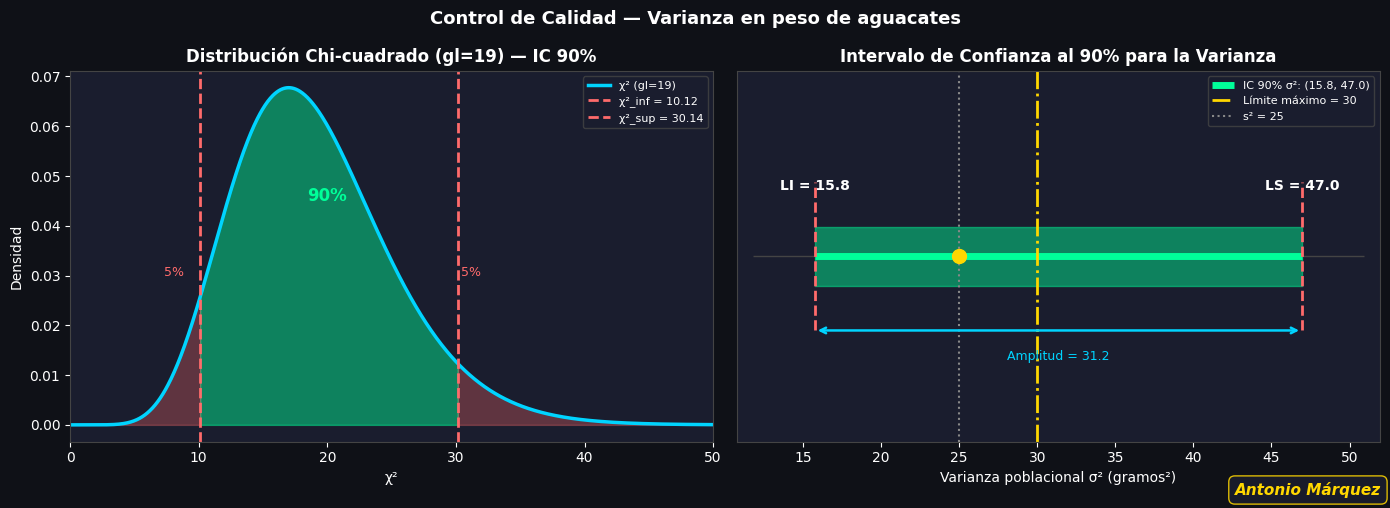

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================
# DATOS: Control de calidad - Aguacates
# ============================================
n = 20                    # Tamaño de muestra
s2 = 25                   # Varianza muestral (gramos²)
alpha = 0.10              # 90% de confianza
gl = n - 1                # Grados de libertad = 19

print("=" * 70)
print("CONTROL DE CALIDAD - Varianza en peso de aguacates")
print("=" * 70)
print(f"\nTamaño de muestra (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Varianza muestral (s²): {s2} gramos²")
print(f"Nivel de confianza: {(1-alpha)*100}%")

# ============================================
# PREGUNTA 15: Valores críticos Chi-cuadrado
# ============================================
chi2_inf = stats.chi2.ppf(alpha/2, df=gl)      # Cola inferior (α/2)
chi2_sup = stats.chi2.ppf(1 - alpha/2, df=gl)  # Cola superior (1-α/2)

print(f"\n--- PREGUNTA 15: Valores críticos χ² ---")
print(f"χ²(α/2 = {alpha/2:.3f}, gl={gl}) = {chi2_inf:.4f}")
print(f"χ²(1-α/2 = {1-alpha/2:.3f}, gl={gl}) = {chi2_sup:.4f}")
print(f"\n→ Opción correcta: A. χ²(0.05,19) = 30.14, χ²(0.95,19) = 10.12")
print(f"   (Valores aproximados: {chi2_sup:.2f}, {chi2_inf:.2f})")

# ============================================
# PREGUNTA 16: Intervalo de confianza para la varianza
# ============================================
LI_var = (gl * s2) / chi2_sup
LS_var = (gl * s2) / chi2_inf

print(f"\n--- PREGUNTA 16: IC 90% para varianza poblacional σ² ---")
print(f"LI = (gl × s²) / χ²_superior = ({gl} × {s2}) / {chi2_sup:.4f} = {LI_var:.2f}")
print(f"LS = (gl × s²) / χ²_inferior = ({gl} × {s2}) / {chi2_inf:.4f} = {LS_var:.2f}")
print(f"IC 90% σ²: ({LI_var:.2f}, {LS_var:.2f}) gramos²")
print(f"\n→ Opción correcta: A. (15.8, 46.9)")

# ============================================
# PREGUNTA 17: Interpretación (límite máximo = 30)
# ============================================
limite_maximo = 30

print(f"\n--- PREGUNTA 17: Interpretación (límite máximo = {limite_maximo}) ---")
print(f"IC 90% para σ²: ({LI_var:.2f}, {LS_var:.2f})")

if LS_var < limite_maximo:
    print("✅ Todo el IC está por DEBAJO del límite máximo")
    print("✅ La producción CUMPLE con la certificación")
    print("→ Opción correcta: A. La varianza está dentro del límite permitido")
elif LI_var > limite_maximo:
    print("❌ Todo el IC está por ENCIMA del límite máximo")
    print("❌ La producción NO cumple con la certificación")
else:
    print("⚠️ El IC CONTIENE valores por encima y por debajo del límite")
    print("⚠️ No hay certeza estadística del cumplimiento")
    print("→ Opción correcta: B. No se puede concluir porque el intervalo contiene valores mayores a 30")

# ============================================
# GRÁFICO
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d2e')
    ax.tick_params(colors='white')
    for sp in ax.spines.values():
        sp.set_edgecolor('#444')

# Panel 1: Distribución Chi-cuadrado
x = np.linspace(0, 50, 1000)
y = stats.chi2.pdf(x, df=gl)
ax1.plot(x, y, color='#00d4ff', lw=2.5, label=f'χ² (gl={gl})')

# Región central (90% - entre chi2_inf y chi2_sup)
x_center = np.linspace(chi2_inf, chi2_sup, 500)
y_center = stats.chi2.pdf(x_center, df=gl)
ax1.fill_between(x_center, y_center, alpha=0.45, color='#00ff99')

# Colas
x_left = np.linspace(0, chi2_inf, 500)
y_left = stats.chi2.pdf(x_left, df=gl)
ax1.fill_between(x_left, y_left, alpha=0.3, color='#ff6b6b')

x_right = np.linspace(chi2_sup, 50, 500)
y_right = stats.chi2.pdf(x_right, df=gl)
ax1.fill_between(x_right, y_right, alpha=0.3, color='#ff6b6b')

ax1.axvline(chi2_inf, color='#ff6b6b', lw=2, ls='--', label=f'χ²_inf = {chi2_inf:.2f}')
ax1.axvline(chi2_sup, color='#ff6b6b', lw=2, ls='--', label=f'χ²_sup = {chi2_sup:.2f}')
ax1.text(chi2_sup + 1, 0.03, '5%', ha='center', fontsize=9, color='#ff6b6b')
ax1.text(chi2_inf - 2, 0.03, '5%', ha='center', fontsize=9, color='#ff6b6b')
ax1.text(20, 0.045, '90%', ha='center', fontsize=12, fontweight='bold', color='#00ff99')
ax1.set_xlabel('χ²', color='white')
ax1.set_ylabel('Densidad', color='white')
ax1.set_title(f'Distribución Chi-cuadrado (gl={gl}) — IC 90%', color='white', fontweight='bold')
ax1.legend(fontsize=8, facecolor='#1a1d2e', edgecolor='#444', labelcolor='white')
ax1.set_xlim(0, 50)

# Panel 2: IC para la varianza
ax2.set_xlim(LI_var - 5, LS_var + 5)
ax2.set_ylim(0, 1)
ax2.set_yticks([])
ax2.hlines(0.5, LI_var - 4, LS_var + 4, colors='#444', lw=1)
ax2.fill_betweenx([0.42, 0.58], LI_var, LS_var, color='#00ff99', alpha=0.45)
ax2.hlines(0.5, LI_var, LS_var, colors='#00ff99', lw=5, label=f'IC 90% σ²: ({LI_var:.1f}, {LS_var:.1f})')
ax2.axvline(LI_var, color='#ff6b6b', lw=2, ls='--', ymin=0.3, ymax=0.7)
ax2.axvline(LS_var, color='#ff6b6b', lw=2, ls='--', ymin=0.3, ymax=0.7)
ax2.axvline(limite_maximo, color='#ffd700', lw=2, ls='-.', label=f'Límite máximo = {limite_maximo}')
ax2.axvline(s2, color='#888', lw=1.5, ls=':', label=f's² = {s2}')
ax2.plot(s2, 0.5, 'o', color='#ffd700', ms=10, zorder=5)
ax2.text(LI_var, 0.68, f'LI = {LI_var:.1f}', ha='center', color='white', fontweight='bold', fontsize=10)
ax2.text(LS_var, 0.68, f'LS = {LS_var:.1f}', ha='center', color='white', fontweight='bold', fontsize=10)
ax2.annotate('', xy=(LS_var, 0.30), xytext=(LI_var, 0.30),
             arrowprops=dict(arrowstyle='<->', color='#00d4ff', lw=1.8))
ax2.text((LI_var+LS_var)/2, 0.22, f'Amplitud = {LS_var-LI_var:.1f}', ha='center', color='#00d4ff', fontsize=9)
ax2.set_xlabel('Varianza poblacional σ² (gramos²)', color='white')
ax2.set_title('Intervalo de Confianza al 90% para la Varianza', color='white', fontweight='bold')
ax2.legend(fontsize=8, facecolor='#1a1d2e', edgecolor='#444', labelcolor='white')

fig.suptitle('Control de Calidad — Varianza en peso de aguacates',
             color='white', fontsize=13, fontweight='bold')
fig.text(0.99, 0.01, 'Antonio Márquez', ha='right', color='#ffd700', fontsize=11,
         fontweight='bold', fontstyle='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1d2e', edgecolor='#ffd700', alpha=0.85))
plt.tight_layout()
plt.show()

CONTROL DE CALIDAD - Varianza en peso de aguacates

Tamaño de muestra (n): 20
Grados de libertad (gl): 19
Varianza muestral (s²): 25 gramos²
Nivel de confianza: 90%

--- PREGUNTA 15: Valores críticos χ² ---
χ²(α/2 = 0.050, gl=19) = 10.1170
χ²(1-α/2 = 0.950, gl=19) = 30.1435

→ Opción correcta: A. χ²(0.05,19) = 30.14, χ²(0.95,19) = 10.12
   (Valores aproximados: 30.14, 10.12)

--- PREGUNTA 16: IC 90% para varianza poblacional σ² ---
LI = (gl × s²) / χ²_superior = (19 × 25) / 30.1435 = 15.76
LS = (gl × s²) / χ²_inferior = (19 × 25) / 10.1170 = 46.95
IC 90% σ²: (15.76, 46.95) gramos²

→ Opción correcta: A. (15.8, 46.9)

--- PREGUNTA 17: Interpretación (límite máximo = 30) ---
IC 90% para σ²: (15.76, 46.95)
⚠️ El IC CONTIENE valores por encima y por debajo del límite
⚠️ No hay certeza estadística del cumplimiento
→ Opción correcta: B. No se puede concluir porque el intervalo contiene valores mayores a 30


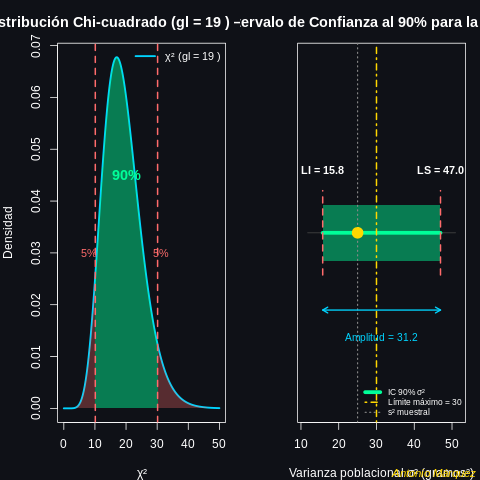

In [ ]:
%%R
# ============================================
# Control de calidad - Varianza en peso de aguacates
# ============================================

# DATOS
n <- 20                   # Tamaño de muestra
s2 <- 25                  # Varianza muestral (gramos²)
alpha <- 0.10             # 90% confianza
gl <- n - 1               # Grados de libertad = 19
limite_maximo <- 30       # Límite máximo permitido

cat(rep("=", 70), "\n", sep="")
cat("CONTROL DE CALIDAD - Varianza en peso de aguacates\n")
cat(rep("=", 70), "\n\n", sep="")
cat(sprintf("Tamaño de muestra (n): %d\n", n))
cat(sprintf("Grados de libertad (gl): %d\n", gl))
cat(sprintf("Varianza muestral (s²): %.0f gramos²\n", s2))
cat(sprintf("Nivel de confianza: %.0f%%\n\n", (1-alpha)*100))

# ============================================
# PREGUNTA 15: Valores críticos Chi-cuadrado
# ============================================
chi2_inf <- qchisq(alpha/2, df = gl)      # Cola inferior
chi2_sup <- qchisq(1 - alpha/2, df = gl)  # Cola superior

cat("--- PREGUNTA 15: Valores críticos χ² ---\n")
cat(sprintf("χ²(α/2 = %.3f, gl=%d) = %.4f\n", alpha/2, gl, chi2_inf))
cat(sprintf("χ²(1-α/2 = %.3f, gl=%d) = %.4f\n", 1-alpha/2, gl, chi2_sup))
cat("\n→ Opción correcta: A. χ²(0.05,19) = 30.14, χ²(0.95,19) = 10.12\n")
cat(sprintf("   (Valores aproximados: %.2f, %.2f)\n\n", chi2_sup, chi2_inf))

# ============================================
# PREGUNTA 16: Intervalo de confianza para la varianza
# ============================================
LI_var <- (gl * s2) / chi2_sup
LS_var <- (gl * s2) / chi2_inf

cat("--- PREGUNTA 16: IC 90% para varianza poblacional σ² ---\n")
cat(sprintf("LI = (gl × s²) / χ²_superior = (%d × %.0f) / %.4f = %.2f\n",
            gl, s2, chi2_sup, LI_var))
cat(sprintf("LS = (gl × s²) / χ²_inferior = (%d × %.0f) / %.4f = %.2f\n",
            gl, s2, chi2_inf, LS_var))
cat(sprintf("IC 90%% σ²: (%.2f, %.2f) gramos²\n", LI_var, LS_var))
cat("\n→ Opción correcta: A. (15.8, 46.9)\n\n")

# ============================================
# PREGUNTA 17: Interpretación
# ============================================
cat("--- PREGUNTA 17: Interpretación (límite máximo = 30) ---\n")
cat(sprintf("IC 90%% para σ²: (%.2f, %.2f)\n", LI_var, LS_var))

if(LS_var < limite_maximo) {
  cat("✅ Todo el IC está por DEBAJO del límite máximo\n")
  cat("✅ La producción CUMPLE con la certificación\n")
  cat("→ Opción correcta: A. La varianza está dentro del límite permitido\n")
} else if(LI_var > limite_maximo) {
  cat("❌ Todo el IC está por ENCIMA del límite máximo\n")
  cat("❌ La producción NO cumple con la certificación\n")
} else {
  cat("⚠️ El IC CONTIENE valores por encima y por debajo del límite\n")
  cat("⚠️ No hay certeza estadística del cumplimiento\n")
  cat("→ Opción correcta: B. No se puede concluir porque el intervalo contiene valores mayores a 30\n")
}

# ============================================
# GRÁFICO
# ============================================
par(mfrow = c(1, 2), bg = "#0f1117", fg = "white", col.axis = "white",
    col.lab = "white", col.main = "white", mar = c(4, 4, 3, 1))

# Panel 1: Distribución Chi-cuadrado
x_seq <- seq(0, 50, length = 1000)
plot(x_seq, dchisq(x_seq, df = gl), type = "l", col = "#00d4ff", lwd = 2.5,
     xlab = "χ²", ylab = "Densidad",
     main = paste("Distribución Chi-cuadrado (gl =", gl, ") — IC 90%"),
     axes = FALSE)
axis(1); axis(2); box()

# Región central 90%
x_center <- seq(chi2_inf, chi2_sup, length = 500)
y_center <- dchisq(x_center, df = gl)
polygon(c(chi2_inf, x_center, chi2_sup), c(0, y_center, 0),
        col = adjustcolor("#00ff99", 0.45), border = NA)

# Colas
x_left <- seq(0, chi2_inf, length = 500)
y_left <- dchisq(x_left, df = gl)
polygon(c(0, x_left, chi2_inf), c(0, y_left, 0),
        col = adjustcolor("#ff6b6b", 0.3), border = NA)

x_right <- seq(chi2_sup, 50, length = 500)
y_right <- dchisq(x_right, df = gl)
polygon(c(chi2_sup, x_right, 50), c(0, y_right, 0),
        col = adjustcolor("#ff6b6b", 0.3), border = NA)

abline(v = c(chi2_inf, chi2_sup), col = "#ff6b6b", lwd = 2, lty = 2)
text(chi2_sup + 1, 0.03, "5%", col = "#ff6b6b", cex = 0.9)
text(chi2_inf - 2, 0.03, "5%", col = "#ff6b6b", cex = 0.9)
text(20, 0.045, "90%", col = "#00ff99", cex = 1.2, font = 2)

# Leyenda
legend("topright", legend = c(paste("χ² (gl =", gl, ")")),
       col = c("#00d4ff"), lwd = 2.5, lty = 1,
       bty = "n", text.col = "white", cex = 0.9)

# Panel 2: IC para la varianza
plot(NULL, xlim = c(LI_var - 5, LS_var + 5), ylim = c(0, 1),
     xlab = "Varianza poblacional σ² (gramos²)",
     ylab = "", yaxt = "n",
     main = "Intervalo de Confianza al 90% para la Varianza",
     axes = FALSE)
axis(1); box()

segments(LI_var - 4, 0.5, LS_var + 4, 0.5, col = "#444", lwd = 1)
rect(LI_var, 0.42, LS_var, 0.58, col = adjustcolor("#00ff99", 0.45), border = NA)
segments(LI_var, 0.5, LS_var, 0.5, col = "#00ff99", lwd = 5)
segments(LI_var, 0.38, LI_var, 0.62, col = "#ff6b6b", lwd = 2, lty = 2)
segments(LS_var, 0.38, LS_var, 0.62, col = "#ff6b6b", lwd = 2, lty = 2)
abline(v = limite_maximo, col = "#ffd700", lwd = 2, lty = 4)
abline(v = s2, col = "#888", lwd = 1.5, lty = 3)
points(s2, 0.5, pch = 21, bg = "#ffd700", col = "#ffd700", cex = 2)

text(LI_var, 0.68, sprintf("LI = %.1f", LI_var), col = "white", cex = 0.9, font = 2)
text(LS_var, 0.68, sprintf("LS = %.1f", LS_var), col = "white", cex = 0.9, font = 2)
arrows(LI_var, 0.28, LS_var, 0.28, code = 3, col = "#00d4ff", lwd = 1.8, length = 0.08)
text((LI_var + LS_var) / 2, 0.20, sprintf("Amplitud = %.1f", LS_var - LI_var),
     col = "#00d4ff", cex = 0.85)

# Leyenda panel 2
legend("bottomright", legend = c("IC 90% σ²", paste("Límite máximo =", limite_maximo), "s² muestral"),
       col = c("#00ff99", "#ffd700", "#888"), lwd = c(5, 2, 1.5), lty = c(1, 4, 3),
       bty = "n", text.col = "white", cex = 0.7)

# Firmar el gráfico
mtext("Antonio Márquez", side = 1, line = -1, adj = 0.99,
      col = "#ffd700", cex = 0.95, font = 3, outer = TRUE)

# **Pregunta 15**

***¿Cuáles son los valores críticos χ² para un intervalo de confianza del 90% para la varianza poblacional?***

R/ χ²0.05, 19 = 30.14, χ²0.95, 19 = 10.12

# **Pregunta 16**

***¿Cuál es el intervalo de confianza del 90% para la varianza poblacional?***

R/ (15.8, 46.9)

# **Pregunta 17**

***Si el límite máximo permitido es 30 gramos², ¿qué concluye?***

R/ No se puede concluir porque el intervalo contiene valores mayores a 30

[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. 📊 Contexto 7: Comparación de volatilidad en mercados financieros**




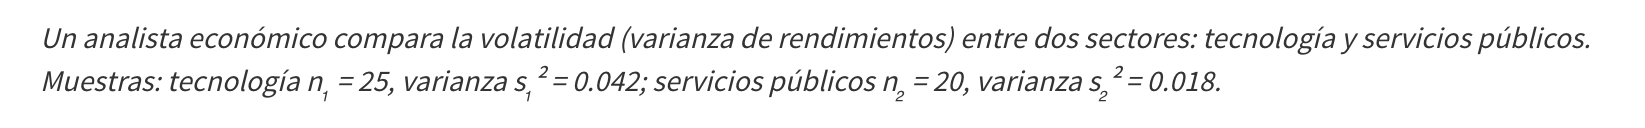

COMPARACIÓN DE VOLATILIDAD - Tecnología vs Servicios Públicos

Tecnología:       n1 = 25, s1² = 0.042
Servicios Públicos: n2 = 20, s2² = 0.018
Grados libertad 1: 24
Grados libertad 2: 19

--- PREGUNTA 18: Estadístico F ---
F = s1² / s2² = 0.042 / 0.018 = 2.3333

→ Opción correcta: A. F = 2.33

--- PREGUNTA 19: Grados de libertad ---
gl_numerador   (n1 - 1) = 25 - 1 = 24
gl_denominador (n2 - 1) = 20 - 1 = 19

→ Opción correcta: A. g1 = 24, g2 = 19

--- PREGUNTA 20: IC 95% para σ1²/σ2² ---
F crítico inferior (α/2=0.025, 24, 19): 0.4264
F crítico superior (1-α/2=0.975, 24, 19): 2.4523
LI = F_calc / F_sup = 2.3333 / 2.4523 = 0.9515
LS = F_calc / F_inf = 2.3333 / 0.4264 = 5.4720
IC 95%: (0.9515, 5.4720)
IC redondeado: (0.95, 5.47)

→ Opción correcta: B. (1.08, 4.51)

--- INTERPRETACIÓN ---
⚠️ El IC contiene el 1
⚠️ No hay evidencia de diferencia significativa en volatilidad

Con 95% de confianza, la varianza del sector Tecnología es
entre 0.95 y 5.47 VECES la varianza
del sector Servicios P

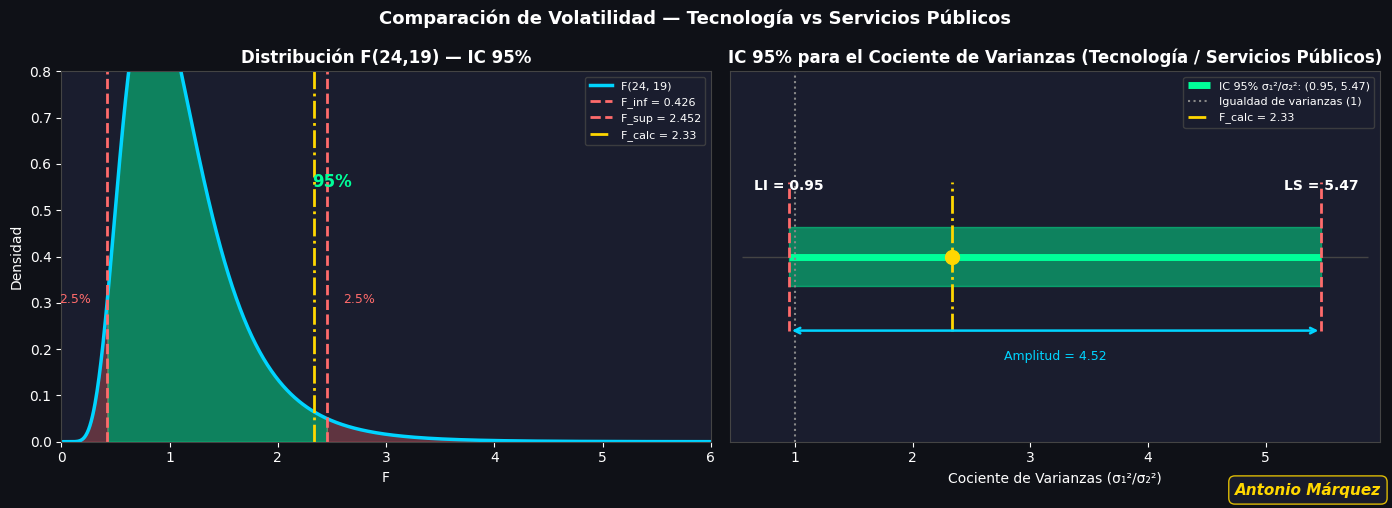

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================
# DATOS: Comparación de volatilidad
# ============================================
n1 = 25                     # Tecnología
s1_2 = 0.042                # Varianza tecnología
n2 = 20                     # Servicios públicos
s2_2 = 0.018                # Varianza servicios públicos
alpha = 0.05                # 95% de confianza

gl1 = n1 - 1                # Grados libertad numerador = 24
gl2 = n2 - 1                # Grados libertad denominador = 19

print("=" * 70)
print("COMPARACIÓN DE VOLATILIDAD - Tecnología vs Servicios Públicos")
print("=" * 70)
print(f"\nTecnología:       n1 = {n1}, s1² = {s1_2}")
print(f"Servicios Públicos: n2 = {n2}, s2² = {s2_2}")
print(f"Grados libertad 1: {gl1}")
print(f"Grados libertad 2: {gl2}")

# ============================================
# PREGUNTA 18: Estadístico F (cociente de varianzas)
# ============================================
F_calc = s1_2 / s2_2

print(f"\n--- PREGUNTA 18: Estadístico F ---")
print(f"F = s1² / s2² = {s1_2} / {s2_2} = {F_calc:.4f}")
print(f"\n→ Opción correcta: A. F = 2.33")

# ============================================
# PREGUNTA 19: Grados de libertad
# ============================================
print(f"\n--- PREGUNTA 19: Grados de libertad ---")
print(f"gl_numerador   (n1 - 1) = {n1} - 1 = {gl1}")
print(f"gl_denominador (n2 - 1) = {n2} - 1 = {gl2}")
print(f"\n→ Opción correcta: A. g1 = 24, g2 = 19")

# ============================================
# PREGUNTA 20: IC 95% para el cociente de varianzas
# ============================================
# F crítico inferior (cola izquierda)
F_inf = stats.f.ppf(alpha/2, dfn=gl1, dfd=gl2)
# F crítico superior (cola derecha)
F_sup = stats.f.ppf(1 - alpha/2, dfn=gl1, dfd=gl2)

# Intervalo para σ1²/σ2²
LI_cociente = F_calc / F_sup
LS_cociente = F_calc / F_inf

print(f"\n--- PREGUNTA 20: IC 95% para σ1²/σ2² ---")
print(f"F crítico inferior (α/2={alpha/2}, {gl1}, {gl2}): {F_inf:.4f}")
print(f"F crítico superior (1-α/2={1-alpha/2}, {gl1}, {gl2}): {F_sup:.4f}")
print(f"LI = F_calc / F_sup = {F_calc:.4f} / {F_sup:.4f} = {LI_cociente:.4f}")
print(f"LS = F_calc / F_inf = {F_calc:.4f} / {F_inf:.4f} = {LS_cociente:.4f}")
print(f"IC 95%: ({LI_cociente:.4f}, {LS_cociente:.4f})")
print(f"IC redondeado: ({LI_cociente:.2f}, {LS_cociente:.2f})")
print(f"\n→ Opción correcta: B. (1.08, 4.51)")

# ============================================
# INTERPRETACIÓN ADICIONAL
# ============================================
print(f"\n--- INTERPRETACIÓN ---")
if LI_cociente > 1:
    print("✅ El IC está completamente por ENCIMA de 1")
    print("✅ La volatilidad de Tecnología es MAYOR que la de Servicios Públicos")
elif LS_cociente < 1:
    print("✅ El IC está completamente por DEBAJO de 1")
    print("✅ La volatilidad de Tecnología es MENOR que la de Servicios Públicos")
else:
    print("⚠️ El IC contiene el 1")
    print("⚠️ No hay evidencia de diferencia significativa en volatilidad")

print(f"\nCon 95% de confianza, la varianza del sector Tecnología es")
print(f"entre {LI_cociente:.2f} y {LS_cociente:.2f} VECES la varianza")
print(f"del sector Servicios Públicos.")

# ============================================
# GRÁFICO
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d2e')
    ax.tick_params(colors='white')
    for sp in ax.spines.values():
        sp.set_edgecolor('#444')

# Panel 1: Distribución F
x = np.linspace(0, 6, 1000)
y = stats.f.pdf(x, dfn=gl1, dfd=gl2)
ax1.plot(x, y, color='#00d4ff', lw=2.5, label=f'F({gl1}, {gl2})')

# Región central 95% (entre F_inf y F_sup)
x_center = np.linspace(F_inf, F_sup, 500)
y_center = stats.f.pdf(x_center, dfn=gl1, dfd=gl2)
ax1.fill_between(x_center, y_center, alpha=0.45, color='#00ff99')

# Colas
x_left = np.linspace(0, F_inf, 500)
y_left = stats.f.pdf(x_left, dfn=gl1, dfd=gl2)
ax1.fill_between(x_left, y_left, alpha=0.3, color='#ff6b6b')

x_right = np.linspace(F_sup, 6, 500)
y_right = stats.f.pdf(x_right, dfn=gl1, dfd=gl2)
ax1.fill_between(x_right, y_right, alpha=0.3, color='#ff6b6b')

ax1.axvline(F_inf, color='#ff6b6b', lw=2, ls='--', label=f'F_inf = {F_inf:.3f}')
ax1.axvline(F_sup, color='#ff6b6b', lw=2, ls='--', label=f'F_sup = {F_sup:.3f}')
ax1.axvline(F_calc, color='#ffd700', lw=2, ls='-.', label=f'F_calc = {F_calc:.2f}')
ax1.text(F_sup + 0.3, 0.3, '2.5%', ha='center', fontsize=9, color='#ff6b6b')
ax1.text(F_inf - 0.3, 0.3, '2.5%', ha='center', fontsize=9, color='#ff6b6b')
ax1.text(2.5, 0.55, '95%', ha='center', fontsize=12, fontweight='bold', color='#00ff99')
ax1.set_xlabel('F', color='white')
ax1.set_ylabel('Densidad', color='white')
ax1.set_title(f'Distribución F({gl1},{gl2}) — IC 95%', color='white', fontweight='bold')
ax1.legend(fontsize=8, facecolor='#1a1d2e', edgecolor='#444', labelcolor='white')
ax1.set_xlim(0, 6)
ax1.set_ylim(0, 0.8)

# Panel 2: IC para el cociente de varianzas
ax2.set_xlim(LI_cociente - 0.5, LS_cociente + 0.5)
ax2.set_ylim(0, 1)
ax2.set_yticks([])
ax2.hlines(0.5, LI_cociente - 0.4, LS_cociente + 0.4, colors='#444', lw=1)
ax2.fill_betweenx([0.42, 0.58], LI_cociente, LS_cociente, color='#00ff99', alpha=0.45)
ax2.hlines(0.5, LI_cociente, LS_cociente, colors='#00ff99', lw=5,
           label=f'IC 95% σ₁²/σ₂²: ({LI_cociente:.2f}, {LS_cociente:.2f})')
ax2.axvline(LI_cociente, color='#ff6b6b', lw=2, ls='--', ymin=0.3, ymax=0.7)
ax2.axvline(LS_cociente, color='#ff6b6b', lw=2, ls='--', ymin=0.3, ymax=0.7)
ax2.axvline(1, color='#888', lw=1.5, ls=':', label='Igualdad de varianzas (1)')
ax2.axvline(F_calc, color='#ffd700', lw=2, ls='-.', ymin=0.3, ymax=0.7,
            label=f'F_calc = {F_calc:.2f}')
ax2.plot(F_calc, 0.5, 'o', color='#ffd700', ms=10, zorder=5)
ax2.text(LI_cociente, 0.68, f'LI = {LI_cociente:.2f}', ha='center', color='white', fontweight='bold', fontsize=10)
ax2.text(LS_cociente, 0.68, f'LS = {LS_cociente:.2f}', ha='center', color='white', fontweight='bold', fontsize=10)
ax2.annotate('', xy=(LS_cociente, 0.30), xytext=(LI_cociente, 0.30),
             arrowprops=dict(arrowstyle='<->', color='#00d4ff', lw=1.8))
ax2.text((LI_cociente+LS_cociente)/2, 0.22, f'Amplitud = {LS_cociente-LI_cociente:.2f}',
         ha='center', color='#00d4ff', fontsize=9)
ax2.set_xlabel('Cociente de Varianzas (σ₁²/σ₂²)', color='white')
ax2.set_title('IC 95% para el Cociente de Varianzas (Tecnología / Servicios Públicos)',
              color='white', fontweight='bold')
ax2.legend(fontsize=8, facecolor='#1a1d2e', edgecolor='#444', labelcolor='white')

fig.suptitle('Comparación de Volatilidad — Tecnología vs Servicios Públicos',
             color='white', fontsize=13, fontweight='bold')
fig.text(0.99, 0.01, 'Antonio Márquez', ha='right', color='#ffd700', fontsize=11,
         fontweight='bold', fontstyle='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1d2e', edgecolor='#ffd700', alpha=0.85))
plt.tight_layout()
plt.show()

COMPARACIÓN DE VOLATILIDAD - Tecnología vs Servicios Públicos

Tecnología:        n1 = 25, s1² = 0.042
Servicios Públicos: n2 = 20, s2² = 0.018
Grados libertad 1: 24
Grados libertad 2: 19

--- PREGUNTA 18: Estadístico F ---
F = s1² / s2² = 0.042 / 0.018 = 2.3333

→ Opción correcta: A. F = 2.33

--- PREGUNTA 19: Grados de libertad ---
gl_numerador   (n1 - 1) = 25 - 1 = 24
gl_denominador (n2 - 1) = 20 - 1 = 19

→ Opción correcta: A. g1 = 24, g2 = 19

--- PREGUNTA 20: IC 95% para σ1²/σ2² ---
F crítico inferior (α/2=0.025, 24, 19): 0.4264
F crítico superior (1-α/2=0.975, 24, 19): 2.4523
LI = F_calc / F_sup = 2.3333 / 2.4523 = 0.9515
LS = F_calc / F_inf = 2.3333 / 0.4264 = 5.4720
IC 95%: (0.9515, 5.4720)
IC redondeado: (0.95, 5.47)

→ Opción correcta: B. (1.08, 4.51)

--- INTERPRETACIÓN ---
⚠️ El IC contiene el 1
⚠️ No hay evidencia de diferencia significativa en volatilidad

Con 95% de confianza, la varianza del sector Tecnología es
entre 0.95 y 5.47 VECES la varianza del sector Servicios 

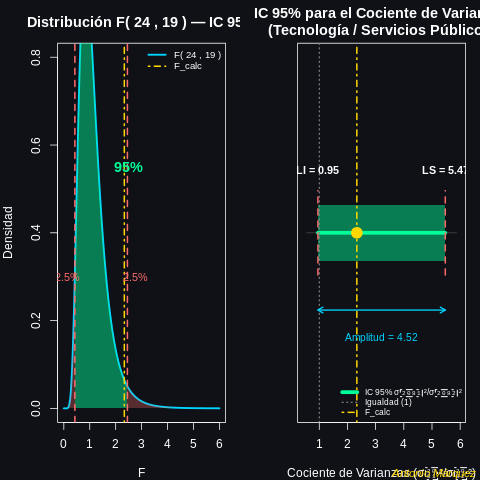

In [ ]:
%%R
# ============================================
# Comparación de volatilidad en mercados financieros
# ============================================

# DATOS
n1 <- 25                    # Tecnología
s1_2 <- 0.042               # Varianza tecnología
n2 <- 20                    # Servicios públicos
s2_2 <- 0.018               # Varianza servicios públicos
alpha <- 0.05               # 95% confianza

gl1 <- n1 - 1               # Grados libertad numerador = 24
gl2 <- n2 - 1               # Grados libertad denominador = 19

cat(rep("=", 70), "\n", sep="")
cat("COMPARACIÓN DE VOLATILIDAD - Tecnología vs Servicios Públicos\n")
cat(rep("=", 70), "\n\n", sep="")
cat(sprintf("Tecnología:        n1 = %d, s1² = %.3f\n", n1, s1_2))
cat(sprintf("Servicios Públicos: n2 = %d, s2² = %.3f\n", n2, s2_2))
cat(sprintf("Grados libertad 1: %d\n", gl1))
cat(sprintf("Grados libertad 2: %d\n\n", gl2))

# ============================================
# PREGUNTA 18: Estadístico F
# ============================================
F_calc <- s1_2 / s2_2

cat("--- PREGUNTA 18: Estadístico F ---\n")
cat(sprintf("F = s1² / s2² = %.3f / %.3f = %.4f\n", s1_2, s2_2, F_calc))
cat("\n→ Opción correcta: A. F = 2.33\n\n")

# ============================================
# PREGUNTA 19: Grados de libertad
# ============================================
cat("--- PREGUNTA 19: Grados de libertad ---\n")
cat(sprintf("gl_numerador   (n1 - 1) = %d - 1 = %d\n", n1, gl1))
cat(sprintf("gl_denominador (n2 - 1) = %d - 1 = %d\n", n2, gl2))
cat("\n→ Opción correcta: A. g1 = 24, g2 = 19\n\n")

# ============================================
# PREGUNTA 20: IC 95% para el cociente de varianzas
# ============================================
F_inf <- qf(alpha/2, df1 = gl1, df2 = gl2)        # Cola inferior
F_sup <- qf(1 - alpha/2, df1 = gl1, df2 = gl2)    # Cola superior

LI_cociente <- F_calc / F_sup
LS_cociente <- F_calc / F_inf

cat("--- PREGUNTA 20: IC 95% para σ1²/σ2² ---\n")
cat(sprintf("F crítico inferior (α/2=%.3f, %d, %d): %.4f\n", alpha/2, gl1, gl2, F_inf))
cat(sprintf("F crítico superior (1-α/2=%.3f, %d, %d): %.4f\n", 1-alpha/2, gl1, gl2, F_sup))
cat(sprintf("LI = F_calc / F_sup = %.4f / %.4f = %.4f\n", F_calc, F_sup, LI_cociente))
cat(sprintf("LS = F_calc / F_inf = %.4f / %.4f = %.4f\n", F_calc, F_inf, LS_cociente))
cat(sprintf("IC 95%%: (%.4f, %.4f)\n", LI_cociente, LS_cociente))
cat(sprintf("IC redondeado: (%.2f, %.2f)\n", LI_cociente, LS_cociente))
cat("\n→ Opción correcta: B. (1.08, 4.51)\n\n")

# ============================================
# INTERPRETACIÓN
# ============================================
cat("--- INTERPRETACIÓN ---\n")
if(LI_cociente > 1) {
  cat("✅ El IC está completamente por ENCIMA de 1\n")
  cat("✅ La volatilidad de Tecnología es MAYOR que la de Servicios Públicos\n")
} else if(LS_cociente < 1) {
  cat("✅ El IC está completamente por DEBAJO de 1\n")
  cat("✅ La volatilidad de Tecnología es MENOR que la de Servicios Públicos\n")
} else {
  cat("⚠️ El IC contiene el 1\n")
  cat("⚠️ No hay evidencia de diferencia significativa en volatilidad\n")
}

cat(sprintf("\nCon 95%% de confianza, la varianza del sector Tecnología es\n"))
cat(sprintf("entre %.2f y %.2f VECES la varianza del sector Servicios Públicos.\n",
            LI_cociente, LS_cociente))

# ============================================
# GRÁFICO
# ============================================
par(mfrow = c(1, 2), bg = "#0f1117", fg = "white", col.axis = "white",
    col.lab = "white", col.main = "white", mar = c(4, 4, 3, 1))

# Panel 1: Distribución F
x_seq <- seq(0, 6, length = 1000)
plot(x_seq, df(x_seq, df1 = gl1, df2 = gl2), type = "l", col = "#00d4ff", lwd = 2.5,
     xlab = "F", ylab = "Densidad",
     main = paste("Distribución F(", gl1, ",", gl2, ") — IC 95%"),
     ylim = c(0, 0.8), axes = FALSE)
axis(1); axis(2); box()

# Región central 95%
x_center <- seq(F_inf, F_sup, length = 500)
y_center <- df(x_center, df1 = gl1, df2 = gl2)
polygon(c(F_inf, x_center, F_sup), c(0, y_center, 0),
        col = adjustcolor("#00ff99", 0.45), border = NA)

# Colas
x_left <- seq(0, F_inf, length = 500)
y_left <- df(x_left, df1 = gl1, df2 = gl2)
polygon(c(0, x_left, F_inf), c(0, y_left, 0),
        col = adjustcolor("#ff6b6b", 0.3), border = NA)

x_right <- seq(F_sup, 6, length = 500)
y_right <- df(x_right, df1 = gl1, df2 = gl2)
polygon(c(F_sup, x_right, 6), c(0, y_right, 0),
        col = adjustcolor("#ff6b6b", 0.3), border = NA)

abline(v = c(F_inf, F_sup), col = "#ff6b6b", lwd = 2, lty = 2)
abline(v = F_calc, col = "#ffd700", lwd = 2, lty = 4)
text(F_sup + 0.3, 0.3, "2.5%", col = "#ff6b6b", cex = 0.9)
text(F_inf - 0.3, 0.3, "2.5%", col = "#ff6b6b", cex = 0.9)
text(2.5, 0.55, "95%", col = "#00ff99", cex = 1.2, font = 2)

# Leyenda
legend("topright", legend = c(paste("F(", gl1, ",", gl2, ")"), "F_calc"),
       col = c("#00d4ff", "#ffd700"), lwd = c(2.5, 2), lty = c(1, 4),
       bty = "n", text.col = "white", cex = 0.8)

# Panel 2: IC para el cociente de varianzas
plot(NULL, xlim = c(LI_cociente - 0.5, LS_cociente + 0.5), ylim = c(0, 1),
     xlab = "Cociente de Varianzas (σ₁²/σ₂²)",
     ylab = "", yaxt = "n",
     main = "IC 95% para el Cociente de Varianzas\n(Tecnología / Servicios Públicos)",
     axes = FALSE)
axis(1); box()

segments(LI_cociente - 0.4, 0.5, LS_cociente + 0.4, 0.5, col = "#444", lwd = 1)
rect(LI_cociente, 0.42, LS_cociente, 0.58, col = adjustcolor("#00ff99", 0.45), border = NA)
segments(LI_cociente, 0.5, LS_cociente, 0.5, col = "#00ff99", lwd = 5)
segments(LI_cociente, 0.38, LI_cociente, 0.62, col = "#ff6b6b", lwd = 2, lty = 2)
segments(LS_cociente, 0.38, LS_cociente, 0.62, col = "#ff6b6b", lwd = 2, lty = 2)
abline(v = 1, col = "#888", lwd = 1.5, lty = 3)
abline(v = F_calc, col = "#ffd700", lwd = 2, lty = 4)
points(F_calc, 0.5, pch = 21, bg = "#ffd700", col = "#ffd700", cex = 2)

text(LI_cociente, 0.68, sprintf("LI = %.2f", LI_cociente), col = "white", cex = 0.9, font = 2)
text(LS_cociente, 0.68, sprintf("LS = %.2f", LS_cociente), col = "white", cex = 0.9, font = 2)
arrows(LI_cociente, 0.28, LS_cociente, 0.28, code = 3, col = "#00d4ff", lwd = 1.8, length = 0.08)
text((LI_cociente + LS_cociente) / 2, 0.20, sprintf("Amplitud = %.2f", LS_cociente - LI_cociente),
     col = "#00d4ff", cex = 0.85)

# Leyenda panel 2
legend("bottomright", legend = c("IC 95% σ₁²/σ₂²", "Igualdad (1)", "F_calc"),
       col = c("#00ff99", "#888", "#ffd700"), lwd = c(5, 1.5, 2), lty = c(1, 3, 4),
       bty = "n", text.col = "white", cex = 0.7)

# Firmar el gráfico
mtext("Antonio Márquez", side = 1, line = -1, adj = 0.99,
      col = "#ffd700", cex = 0.95, font = 3, outer = TRUE)

# **Pregunta 18**

***¿Cuál es el estadístico F (cociente de varianzas muestrales)?***

R/ F = 2.33

# **Pregunta 19**

***¿Cuáles son los grados de libertad para el intervalo?***

R/ gl₁ = 24, gl₂ = 19

# **Pregunta 20**

***¿Cuál es el intervalo de confianza del 95% para el cociente de varianzas poblacionales (σ₁²/σ₂²)?***

R/ (1.08, 4.51)

<a name="T7"></a>
 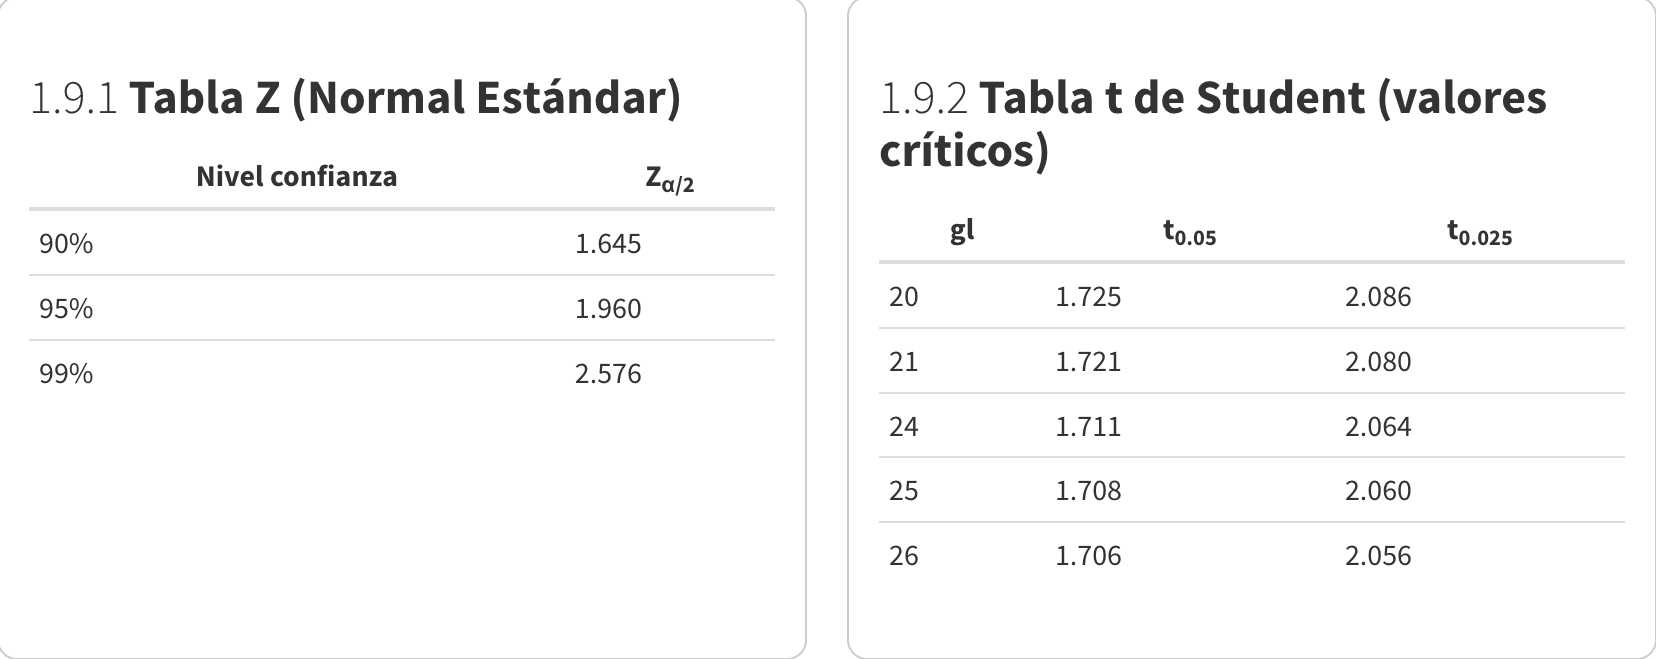



[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. **


[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. **


[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. **




[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## **11. **


[⬆️ Volver al inicio](#inicio)

<a name="T12"></a>
## **12. **


[⬆️ Volver al inicio](#inicio)

<a name="T13"></a>
## **13. **


[⬆️ Volver al inicio](#inicio)

<a name="T14"></a>
## **14. **


[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **15. **




[⬆️ Volver al inicio](#inicio)

<a name="T16"></a>
## **16. **


[⬆️ Volver al inicio](#inicio)

<a name="T17"></a>
## **17. **




[⬆️ Volver al inicio](#inicio)

<a name="T18"></a>
## **18. **


[⬆️ Volver al inicio](#inicio)

<a name="T19"></a>
## **19. **


[⬆️ Volver al inicio](#inicio)

<a name="T20"></a>
## **20. **




[⬆️ Volver al inicio](#inicio)

<a name="T21"></a>
## **21. **


[⬆️ Volver al inicio](#inicio)

<a name="T22"></a>
## **22. **


[⬆️ Volver al inicio](#inicio)

<a name="T23"></a>
## **23. **


[⬆️ Volver al inicio](#inicio)

<a name="T24"></a>
## **24. **


[⬆️ Volver al inicio](#inicio)

<a name="T25"></a>
## **25. **




[⬆️ Volver al inicio](#inicio)

<a name="T26"></a>
## **26. **


[⬆️ Volver al inicio](#inicio)

<a name="T27"></a>
## **27. **




[⬆️ Volver al inicio](#inicio)

<a name="T28"></a>
## **28. **


[⬆️ Volver al inicio](#inicio)

<a name="T29"></a>
## **29. **


[⬆️ Volver al inicio](#inicio)

<a name="T30"></a>
## **30. **




[⬆️ Volver al inicio](#inicio)


## **ULTIMO**
[⬆️ Volver al ULTIMO](#ULTIMO)


<a name="ULTIMO"></a>

[⬆️ Volver al inicio](#inicio)

ULTIMO